In [2]:
# Check conda environment
import sys
import subprocess
import logging

# Reduce verbosity of provider initialization logs
logging.getLogger('provider.ratelimit').setLevel(logging.WARNING)
logging.getLogger('provider.groq').setLevel(logging.WARNING)

# Verify tlw environment is activated
if 'tlw' not in sys.executable.lower() and 'tlw' not in sys.prefix.lower():
    print("WARNING: conda environment 'tlw' is not activated!")
    print("Please run: conda activate tlw")
    print(f"Current Python: {sys.executable}")
else:
    print("✓ Conda environment 'tlw' is active")
    print(f"Python: {sys.executable}")

✓ Conda environment 'tlw' is active
Python: c:\Users\ham25\.conda\envs\tlw\python.exe


# Hyperparameter Tuning Experiment

Complete hyperparameter optimization for SimplifiedTeachingLoop:
- **Phase 0**: Baseline measurement
- **Phase 1**: Teacher-Student combinations (3x3 = 9 experiments)
- **Phase 2A**: Latin Hypercube Sampling (20 configs)
- **Phase 2B**: Focused grid refinement (24 configs)
- **Phase 3**: Judge consistency analysis
- **Phase 4**: Cross-domain testing (Alpaca vs Medical)

**Important**: Ensure conda environment `tlw` is activated before running.

## Setup: All Imports and Configuration

In [3]:
# Standard library
import os
import sys
import json
import yaml
import tempfile
import subprocess
from pathlib import Path
from typing import Dict, List, Any, Optional
from dataclasses import dataclass, asdict
from datetime import datetime
import time

# Scientific computing
import numpy as np
from scipy.stats import qmc, pearsonr

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
# Note: notebooks folder is inside project, need to go up one level
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Checking if simplified_teaching_loop.py exists: {(project_root / 'simplified_teaching_loop.py').exists()}")

# Import project modules
from simplified_teaching_loop import SimplifiedTeachingLoop

# Configure visualization
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print(f"✓ All imports loaded")
print(f"✓ Python path configured")

Project root: c:\Users\ham25\Desktop\Teaching-light-weight-llm-based-project
Checking if simplified_teaching_loop.py exists: True


c:\Users\ham25\.conda\envs\tlw\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports loaded
✓ Python path configured


In [4]:
# Load base configuration
config_path = project_root / "config" / "simplified_config.yml"

with open(config_path) as f:
    base_config = yaml.safe_load(f)

print("Base configuration loaded")
print(f"Student model: {base_config['student']['model']}")
print(f"Teacher model: {base_config['teacher']['model']}")

Base configuration loaded
Student model: llama-3.1-8b-instant
Teacher model: llama-3.3-70b-versatile


## Dataset Preparation

In [4]:
def load_dataset(file_path: str, max_samples: Optional[int] = None) -> List[Dict]:
    """
    Load JSONL dataset.
    
    Args:
        file_path: Path to JSONL file
        max_samples: Maximum number of samples to load
    
    Returns:
        List of question-answer dicts
    """
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_samples and i >= max_samples:
                break
            record = json.loads(line)
            data.append({
                'question': record['question'],
                'reference': record.get('answer') or record.get('reference'),
                'id': record.get('id', f'q_{i}')
            })
    return data

# Load datasets (use project_root for correct path)
alpaca_data = load_dataset(str(project_root / 'data' / 'alpaca_20.jsonl'), max_samples=10)
medical_data = load_dataset(str(project_root / 'data' / 'medical_100.jsonl'), max_samples=10)

print(f"Loaded {len(alpaca_data)} Alpaca questions")
print(f"Loaded {len(medical_data)} Medical questions")

# Combine for baseline test
baseline_dataset = alpaca_data + medical_data
print(f"Total baseline dataset: {len(baseline_dataset)} questions")

Loaded 10 Alpaca questions
Loaded 10 Medical questions
Total baseline dataset: 20 questions


## Helper Functions

In [5]:
def create_temp_config(base_config: Dict, overrides: Dict) -> str:
    """
    Create temporary config file with overrides.
    
    Args:
        base_config: Base configuration dict
        overrides: Dictionary of override values
    
    Returns:
        Path to temporary config file
    """
    # Deep copy base config
    temp_config = json.loads(json.dumps(base_config))
    
    # Apply overrides
    for key_path, value in overrides.items():
        keys = key_path.split('.')
        target = temp_config
        for key in keys[:-1]:
            if key not in target:
                target[key] = {}
            target = target[key]
        target[keys[-1]] = value
    
    # Write to temp file
    temp_file = tempfile.NamedTemporaryFile(mode='w', suffix='.yml', delete=False, encoding='utf-8')
    yaml.dump(temp_config, temp_file, default_flow_style=False)
    temp_file.close()
    
    return temp_file.name

def parse_result(result: Dict) -> Dict[str, float]:
    """
    Parse SimplifiedTeachingLoop result to extract metrics.
    
    Args:
        result: Result dict from SimplifiedTeachingLoop.run()
    
    Returns:
        Dict with extracted metrics
    """
    if not result['history']:
        return {
            'exact_match': 0.0,
            'rouge_l': 0.0,
            'semantic_similarity': 0.0,
            'blind_judge': 0.0,
            'comparison_judge': 0.0
        }
    
    last_round = result['history'][-1]
    scores = last_round.get('scores', {})
    
    return {
        'exact_match': scores.get('exact_match', 0.0),
        'rouge_l': scores.get('rouge_l', 0.0),
        'semantic_similarity': scores.get('semantic_sim', 0.0),  # Fixed: semantic_sim not semantic_similarity
        'blind_judge': scores.get('blind_score', 0.0),  # Fixed: blind_score not blind_judge
        'comparison_judge': scores.get('comparison_score', 0.0)  # Fixed: comparison_score not comparison_judge
    }

print("Helper functions ready")

Helper functions ready


## Experiment Results Storage

In [6]:
@dataclass
class ExperimentResult:
    """
    Single experiment result.
    """
    experiment_id: str
    phase: str
    config: Dict[str, Any]
    metrics: Dict[str, float]
    avg_rounds: float
    total_tokens: int
    cost: float
    timestamp: str
    
    def to_dict(self):
        return asdict(self)

class ExperimentTracker:
    """
    Track all experiment results.
    """
    def __init__(self, output_dir: str = "logs/experiments/hyperparameter_tuning"):
        # Use absolute path to project root to avoid saving in notebooks/logs/
        if not Path(output_dir).is_absolute():
            output_dir = str(project_root / output_dir)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        self.results = []
        self.run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
        
    def add_result(self, result: ExperimentResult):
        self.results.append(result)
        
    def save(self):
        output_file = self.output_dir / f"results_{self.run_id}.jsonl"
        with open(output_file, 'w') as f:
            for result in self.results:
                f.write(json.dumps(result.to_dict()) + '\n')
        print(f"Results saved to {output_file}")
        
    def get_best(self, metric: str = 'exact_match', phase: Optional[str] = None):
        filtered = self.results
        if phase:
            filtered = [r for r in filtered if r.phase == phase]
        if not filtered:
            return None
        return max(filtered, key=lambda r: r.metrics.get(metric, 0))

tracker = ExperimentTracker()
print(f"Experiment tracker initialized: {tracker.run_id}")

Experiment tracker initialized: 20251117_193822


## Phase 0: Baseline Measurement

Student answers directly without teacher intervention.

In [65]:
def run_baseline(dataset: List[Dict], base_config: Dict) -> tuple[Dict[str, float], int, List[Dict]]:
    """
    Run baseline experiment - pure student performance without teacher/memory.
    BUT we still need full evaluation (including judges) to measure quality!
    
    Args:
        dataset: List of questions
        base_config: Base configuration dict
    
    Returns:
        Tuple of (aggregated_metrics, total_tokens, detailed_results)
    """
    from src.providers.factory import build_client
    from src.eval.metrics import exact_match, rouge_scores, semantic_similarity
    
    # Initialize student AND judges (we need them to evaluate!)
    student_config = base_config['student']
    student = build_client(
        provider=student_config['provider'],
        model=student_config['model']
    )
    
    # Initialize judges for scoring
    judge_config = base_config.get('hybrid_scoring', {})
    
    blind_judge_cfg = judge_config.get('blind_judge', {})
    blind_judge = build_client(
        provider=blind_judge_cfg.get('provider', 'groq'),
        model=blind_judge_cfg.get('model', 'llama-3.1-8b-instant')
    )
    
    comparison_judge_cfg = judge_config.get('comparison_judge', {})
    comparison_judge = build_client(
        provider=comparison_judge_cfg.get('provider', 'groq'),
        model=comparison_judge_cfg.get('model', 'llama-3.3-70b-versatile')
    )
    
    results = []
    total_tokens = 0
    
    print(f"Testing {len(dataset)} questions (student only, but WITH full evaluation)...")
    
    for i, item in enumerate(dataset, 1):
        # Student answers directly (no teacher feedback)
        question = item['question']
        reference = item['reference']
        
        messages = [{"role": "user", "content": f"Answer this question concisely:\n\nQuestion: {question}\n\nAnswer:"}]
        response = student.chat(
            messages=messages,
            temperature=student_config.get('temperature', 0.7),
            max_tokens=student_config.get('max_tokens', 512)
        )
        answer = response.text.strip()
        
        # Track tokens from student
        total_tokens += response.usage.total_tokens
        
        # Evaluate with ALL metrics (deterministic + judges)
        em = exact_match(answer, reference)
        rouge = rouge_scores(answer, reference)
        sem_sim = semantic_similarity(answer, reference)
        
        # Blind judge (quality without ground truth)
        blind_prompt = f"""Rate the quality of this answer on a scale of 0.0 to 1.0.

Question: {question}
Answer: {answer}

Consider: clarity, completeness, coherence.
Respond with ONLY a number between 0.0 and 1.0."""

        blind_response = blind_judge.chat(
            messages=[{"role": "user", "content": blind_prompt}],
            temperature=0.2,
            max_tokens=10
        )
        total_tokens += blind_response.usage.total_tokens
        
        try:
            blind_score = float(blind_response.text.strip())
            blind_score = max(0.0, min(1.0, blind_score))
        except:
            blind_score = 0.0
        
        # Comparison judge (accuracy with ground truth)
        comp_prompt = f"""Compare the student answer with the reference answer.
Rate accuracy from 0.0 (completely wrong) to 1.0 (perfect match).

Question: {question}
Reference Answer: {reference}
Student Answer: {answer}

Respond with ONLY a number between 0.0 and 1.0."""

        comp_response = comparison_judge.chat(
            messages=[{"role": "user", "content": comp_prompt}],
            temperature=0.2,
            max_tokens=10
        )
        total_tokens += comp_response.usage.total_tokens
        
        try:
            comp_score = float(comp_response.text.strip())
            comp_score = max(0.0, min(1.0, comp_score))
        except:
            comp_score = 0.0
        
        scores = {
            'exact_match': em,
            'rouge_l': rouge['rouge-l'],
            'semantic_similarity': sem_sim,
            'blind_judge': blind_score,
            'comparison_judge': comp_score
        }
        
        # Store detailed result for debugging
        results.append({
            'id': item.get('id', f'q_{i}'),
            'question': question,
            'reference': reference,
            'answer': answer,
            'scores': scores,
            'tokens': response.usage.total_tokens + blind_response.usage.total_tokens + comp_response.usage.total_tokens
        })
        
        if i % 5 == 0:
            print(f"  Progress: {i}/{len(dataset)}")
    
    # Aggregate metrics
    metrics = {
        'exact_match': sum(r['scores']['exact_match'] for r in results) / len(results),
        'rouge_l': sum(r['scores']['rouge_l'] for r in results) / len(results),
        'semantic_similarity': sum(r['scores']['semantic_similarity'] for r in results) / len(results),
        'blind_judge': sum(r['scores']['blind_judge'] for r in results) / len(results),
        'comparison_judge': sum(r['scores']['comparison_judge'] for r in results) / len(results),
    }
    
    return metrics, total_tokens, results

In [66]:
# Run Phase 0
print("Running Phase 0: Baseline")
print(f"Testing {len(baseline_dataset)} questions")

baseline_metrics, total_tokens, detailed_results = run_baseline(baseline_dataset, base_config)

# Calculate cost (Groq pricing: ~$0.10 per 1M tokens for 8B, ~$0.60 per 1M tokens for 70B)
# Rough estimate: student (8B) + blind (8B) + comparison (70B)
estimated_cost = (total_tokens / 1_000_000) * 0.15

# Store result
baseline_result = ExperimentResult(
    experiment_id="phase0_baseline",
    phase="phase0",
    config={"max_rounds": 1, "enable_teacher": False, "enable_judges": True},
    metrics=baseline_metrics,
    avg_rounds=1.0,
    total_tokens=total_tokens,
    cost=estimated_cost,
    timestamp=datetime.now().isoformat()
)
tracker.add_result(baseline_result)

# Save detailed results for debugging
debug_log_path = tracker.output_dir / f"phase0_baseline_{tracker.run_id}.jsonl"
with open(debug_log_path, 'w', encoding='utf-8') as f:
    for result in detailed_results:
        f.write(json.dumps(result, ensure_ascii=False) + '\n')

print("\nBaseline Results:")
for metric, value in baseline_metrics.items():
    print(f"  {metric}: {value:.3f}")
print(f"\nToken Usage: {total_tokens:,}")
print(f"Estimated Cost: ${estimated_cost:.4f}")
print(f"Debug log saved to: {debug_log_path}")

tracker.save()

Running Phase 0: Baseline
Testing 20 questions
Testing 20 questions (student only, but WITH full evaluation)...
  Progress: 5/20
  Progress: 5/20
  Progress: 10/20
  Progress: 10/20
  Progress: 15/20
  Progress: 15/20
  Progress: 20/20

Baseline Results:
  exact_match: 0.050
  rouge_l: 0.379
  semantic_similarity: 0.731
  blind_judge: 0.885
  comparison_judge: 0.730

Token Usage: 10,014
Estimated Cost: $0.0015
Debug log saved to: c:\Users\ham25\Desktop\Teaching-light-weight-llm-based-project\logs\experiments\hyperparameter_tuning\phase0_baseline_20251116_173009.jsonl
Results saved to c:\Users\ham25\Desktop\Teaching-light-weight-llm-based-project\logs\experiments\hyperparameter_tuning\results_20251116_173009.jsonl
  Progress: 20/20

Baseline Results:
  exact_match: 0.050
  rouge_l: 0.379
  semantic_similarity: 0.731
  blind_judge: 0.885
  comparison_judge: 0.730

Token Usage: 10,014
Estimated Cost: $0.0015
Debug log saved to: c:\Users\ham25\Desktop\Teaching-light-weight-llm-based-projec

## Phase 1: Teacher-Student Combinations

Test 12 combinations (3 teachers x 4 students) to find synergy.


In [7]:
# Phase 1: Teacher and student prompt strategies
# Teachers: Template, CoT, Socratic (3)
teacher_variants = [
    {'key': 'template_feedback', 'style': 'template', 'name': 'Template'},
    {'key': 'cot_feedback',      'style': 'cot',      'name': 'CoT'},
    {'key': 'socratic_feedback', 'style': 'socratic', 'name': 'Socratic'},
]

# Students: Simple, Structured, Reflective, Minimal (4)
student_variants = [
    {
        'key': 'simple_minimal',
        'name': 'Simple',
        'first_key': 'simple_minimal',
        'refine_key': 'simple_minimal_refine',
    },
    {
        'key': 'structured',
        'name': 'Structured',
        'first_key': 'structured_first',
        'refine_key': 'structured_refine',
    },
    {
        'key': 'reflective',
        'name': 'Reflective',
        'first_key': 'reflective_first',
        'refine_key': 'reflective_refine',
    },
    {
        'key': 'minimal',
        'name': 'Minimal',
        'first_key': 'first_attempt',
        'refine_key': 'refinement',
    },
]

# Compatibility dicts for later analysis code
teacher_strategies = {
    t['key']: {
        'name': t['name'],
        'description': f"style={t['style']}",
    }
    for t in teacher_variants
}
student_strategies = {
    s['key']: {
        'name': s['name'],
        'first_key': s['first_key'],
        'refine_key': s['refine_key'],
        'description': s['name'],
    }
    for s in student_variants
}

print(f"Teacher strategies: {len(teacher_variants)}")
print(f"Student strategies: {len(student_variants)}")
print(f"Total combinations: {len(teacher_variants) * len(student_variants)}")

Teacher strategies: 3
Student strategies: 4
Total combinations: 12


In [8]:
def run_teacher_student_experiment(
    teacher_key: str,
    student_first_key: str,
    student_refine_key: str,
    dataset: List[Dict],
    base_config: Dict,
    max_rounds: int = 3
) -> Dict[str, Any]:
    """
    Run experiment with specific teacher-student combination.
    
    **NOW FULLY FUNCTIONAL**: Tests different teacher feedback strategies!
    
    Teacher Strategies:
    - 'feedback' → CoT reasoning (analytical, detailed)
    - 'template_feedback' → Template-based (concrete structure with placeholders)
    - 'socratic_feedback' → Socratic questioning (guiding questions)
    
    Student Strategies:
    - 'first_attempt', 'refinement' → Minimal prompting
    - 'structured_first', 'structured_refine' → Enforced structure with reasoning
    - 'reflective_first', 'reflective_refine' → Metacognitive self-diagnosis
    
    Args:
        teacher_key: Teacher feedback style ('feedback', 'template_feedback', 'socratic_feedback')
        student_first_key: Student first attempt prompt key
        student_refine_key: Student refinement prompt key
        dataset: Questions to test
        base_config: Base configuration dict
        max_rounds: Maximum refinement rounds
    
    Returns:
        Results dict with metrics, metadata, and memory stats
    """
    
    # Map teacher keys to feedback_style values
    teacher_style_map = {
    'feedback':          'cot',
    'cot_feedback':      'cot',
    'template_feedback': 'template',
    'socratic_feedback': 'socratic',
    }
    
    feedback_style = teacher_style_map.get(teacher_key, 'cot')
    
    # Build config overrides with teacher feedback style
    # Phase 1: disable LAST_CHANCE ground-truth tricks to observe pure learning
    overrides = {
        'teacher.feedback_style': feedback_style,  # Teacher strategy selection (cot/template/socratic)
        'loop.max_rounds': max_rounds,
        'loop.enable_last_chance': False,
        'memory.top_k': base_config['memory']['top_k'],
        'memory.similarity_threshold': base_config['memory']['similarity_threshold']
    }
    
    config_path = create_temp_config(base_config, overrides)
    
    try:
        # Run teaching loop with specific teacher strategy
        loop = SimplifiedTeachingLoop(config_path)
        # Log full configuration for this experiment run
        loop.debug_logger.log_parameters(loop.config)
        
        results = []
        memory_hits_total = 0  # Track memory usage across all questions
        
        for item in dataset:
            # Run teaching loop with explicit student strategy prompts
            result = loop.run(
                question=item['question'],
                ground_truth=item['reference'],
                max_rounds=max_rounds,
                student_first_key=student_first_key,
                student_refine_key=student_refine_key,
            )
            results.append(result)
            
            # Count memory retrievals (check if memory was used in round 1)
            if result.get('history') and len(result['history']) > 0:
                first_round = result['history'][0]
                # Memory is only checked in round 1 (see simplified_teaching_loop.py line 234)
                if first_round.get('memory_used') or 'memory_feedback' in first_round:
                    memory_hits_total += 1
        
        # Aggregate metrics using helper function
        all_metrics = [parse_result(r) for r in results]
        metrics = {
            'exact_match': sum(m['exact_match'] for m in all_metrics) / len(all_metrics),
            'rouge_l': sum(m['rouge_l'] for m in all_metrics) / len(all_metrics),
            'semantic_similarity': sum(m['semantic_similarity'] for m in all_metrics) / len(all_metrics),
            'blind_judge': sum(m['blind_judge'] for m in all_metrics) / len(all_metrics),
            'comparison_judge': sum(m['comparison_judge'] for m in all_metrics) / len(all_metrics),
        }
        
        avg_rounds = sum(r['num_rounds'] for r in results) / len(results)
        
        return {
            'metrics': metrics,
            'avg_rounds': avg_rounds,
            'teacher': teacher_key,  # Teacher strategy (now functionally used!)
            'teacher_style': feedback_style,  # Actual style used (cot/template/socratic)
            'student_first': student_first_key,  # Used in prompts
            'student_refine': student_refine_key,  # Used in prompts
            'memory_hits': memory_hits_total,  # How many questions retrieved memory
            'memory_hit_rate': memory_hits_total / len(dataset) if len(dataset) > 0 else 0.0,
            'total_questions': len(dataset)
        }
    finally:
        if os.path.exists(config_path):
            os.unlink(config_path)

print("Phase 1 experiment runner ready")
print("\n FULLY FUNCTIONAL:")
print("   - Tests 3 teacher strategies: CoT, Template, Socratic")
print("   - Tests 4 student strategies: Simple, Minimal, Structured, Reflective")
print("   - Total: 12 combinations (3 x 4)")
print("   - Tracks memory usage for each experiment")

Phase 1 experiment runner ready

 FULLY FUNCTIONAL:
   - Tests 3 teacher strategies: CoT, Template, Socratic
   - Tests 4 student strategies: Simple, Minimal, Structured, Reflective
   - Total: 12 combinations (3 x 4)
   - Tracks memory usage for each experiment


In [12]:
# Run Phase 1: Teacher-Student grid (PLAN B)
# Note: This cell takes ~1.5 hours to complete
# Progress will be printed as experiments run

from pathlib import Path

print("="*80)
print("PHASE 1: TEACHER-STUDENT COMBINATIONS (PLAN B)")
print("="*80)
print(f"\nTotal experiments: {len(teacher_strategies) * len(student_strategies)}")
print(f"Questions per experiment: 20 (10 Alpaca + 10 Medical)")
print(f"Max rounds per question: 3")
print(f"Estimated time: ~1.5 hours")
print(f"Estimated cost: ~$0.80\n")

print("🎯 Testing Strategies:")
print("\nTeachers:")
for key, info in teacher_strategies.items():
    print(f"  • {info['name']}: {info['description']}")
print("\nStudents:")
for key, info in student_strategies.items():
    print(f"  • {info['name']}: {info['description']}")
print("\n" + "="*80 + "\n")

phase1_results = []
experiment_count = 0

for teacher_key, teacher_info in teacher_strategies.items():
    for student_key, student_info in student_strategies.items():
        experiment_count += 1
        print(f"\n{'='*60}")
        print(f"[{experiment_count}/12] {teacher_info['name']} + {student_info['name']}")
        print(f"{'='*60}")
        
        # Prepare dataset: 10 Alpaca + 10 Medical
        alpaca_sample = load_dataset(str(project_root / 'data' / 'alpaca_100.jsonl'), max_samples=10)
        medical_sample = load_dataset(str(project_root / 'data' / 'medical_100.jsonl'), max_samples=10)
        experiment_dataset = alpaca_sample + medical_sample
        
        start_time = time.time()
        try:
            result = run_teacher_student_experiment(
                teacher_key=teacher_key,
                student_first_key=student_info['first_key'],
                student_refine_key=student_info['refine_key'],
                dataset=experiment_dataset,
                base_config=base_config,
                max_rounds=3
            )
            elapsed = time.time() - start_time
            
            # Store result
            exp_result = ExperimentResult(
                experiment_id=f"phase1_{teacher_key}_{student_key}",
                phase="phase1",
                config={
                    'teacher': teacher_key,
                    'teacher_style': result['teacher_style'],  # Actual feedback style used
                    'student': student_key,
                    'student_first_key': student_info['first_key'],
                    'student_refine_key': student_info['refine_key'],
                    'max_rounds': 3,
                    'memory_hits': result['memory_hits'],
                    'memory_hit_rate': result['memory_hit_rate']
                },
                metrics=result['metrics'],
                avg_rounds=result['avg_rounds'],
                total_tokens=0,
                cost=0.0,
                timestamp=datetime.now().isoformat()
            )
            tracker.add_result(exp_result)
            phase1_results.append(result)
            
            print(f"\n📊 Results:")
            print(f"  Exact Match: {result['metrics']['exact_match']:.3f}")
            print(f"  ROUGE-L: {result['metrics']['rouge_l']:.3f}")
            print(f"  Semantic Sim: {result['metrics']['semantic_similarity']:.3f}")
            print(f"  Blind Judge: {result['metrics']['blind_judge']:.3f}")
            print(f"  Comparison Judge: {result['metrics']['comparison_judge']:.3f}")
            print(f"  Avg Rounds: {result['avg_rounds']:.2f}")
            print(f"  Memory Hits: {result['memory_hits']}/{result['total_questions']} ({result['memory_hit_rate']*100:.1f}%)")
            print(f"  Time: {elapsed:.1f}s ({elapsed/60:.1f} min)")
            
            # Save after each experiment
            tracker.save()
            
        except Exception as e:
            print(f"\n❌ ERROR in experiment {experiment_count}:")
            print(f"   {str(e)}")
            import traceback
            traceback.print_exc()
            continue

print("\n" + "="*80)
print("PHASE 1 COMPLETE!")
print("="*80)
print(f"\nTotal successful experiments: {len(phase1_results)}/12")
print(f"\n📈 Memory Usage Summary:")
total_hits = sum(r['memory_hits'] for r in phase1_results)
total_questions = sum(r['total_questions'] for r in phase1_results)
print(f"  Total memory hits: {total_hits}/{total_questions} ({100*total_hits/total_questions:.1f}%)")
print(f"  Average hit rate: {sum(r['memory_hit_rate'] for r in phase1_results)/len(phase1_results)*100:.1f}%")

# Save locations summary
results_path = tracker.output_dir / f"results_{tracker.run_id}.jsonl"
memory_path = Path(base_config["memory"]["storage_path"])
index_path = Path(base_config["memory"]["index_path"])
debug_dir = Path(base_config["logging"]["log_path"]) / "debug"

print("\nSave locations:")
print("  Results file:       ", results_path)
print("  Memory storage:     ", memory_path)
print("  FAISS index:        ", index_path)
print("  Debug logs dir:     ", debug_dir)
print("    - Full debug:     <timestamp>.json")
print("    - Flat debug:     <timestamp>_flat.jsonl")


PHASE 1: TEACHER-STUDENT COMBINATIONS (PLAN B)

Total experiments: 12
Questions per experiment: 20 (10 Alpaca + 10 Medical)
Max rounds per question: 3
Estimated time: ~1.5 hours
Estimated cost: ~$0.80

🎯 Testing Strategies:

Teachers:
  • Template: style=template
  • CoT: style=cot
  • Socratic: style=socratic

Students:
  • Simple: Simple
  • Structured: Structured
  • Reflective: Reflective
  • Minimal: Minimal



[1/12] Template + Simple
2025-11-17 21:45:04,624 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-11-17 21:45:04,625 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-17 21:45:04,625 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-17 21:45:04,643 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6

In [11]:
# Analyze Phase 1 results
print("Phase 1 Results Summary:\n")

# Sort by exact match
phase1_sorted = sorted(phase1_results, key=lambda r: r['metrics']['exact_match'], reverse=True)

print("Top 5 Combinations (by Exact Match):")
for i, result in enumerate(phase1_sorted[:5], 1):
    teacher_name = teacher_strategies[result['teacher']]['name']
    student_key = result.get('student_first', 'default')
    # Find student strategy name
    student_name = 'Unknown'
    for sk, si in student_strategies.items():
        if si['first_key'] == student_key:
            student_name = si['name']
            break
    print(f"{i}. {teacher_name} + {student_name}")
    print(f"   Exact Match: {result['metrics']['exact_match']:.3f}")
    print(f"   ROUGE-L: {result['metrics']['rouge_l']:.3f}")
    print(f"   Avg Rounds: {result['avg_rounds']:.2f}")
    print()

# Store top 3 for Phase 2
top3_combos = phase1_sorted[:3]
print(f"Top 3 combinations selected for Phase 2")

Phase 1 Results Summary:

Top 5 Combinations (by Exact Match):
1. CoT + Minimal
   Exact Match: 0.250
   ROUGE-L: 0.649
   Avg Rounds: 1.65

2. Template + Simple
   Exact Match: 0.200
   ROUGE-L: 0.644
   Avg Rounds: 1.80

3. Template + Minimal
   Exact Match: 0.200
   ROUGE-L: 0.592
   Avg Rounds: 1.80

4. CoT + Simple
   Exact Match: 0.200
   ROUGE-L: 0.662
   Avg Rounds: 1.75

5. Socratic + Simple
   Exact Match: 0.200
   ROUGE-L: 0.607
   Avg Rounds: 1.85

Top 3 combinations selected for Phase 2


## phase 2

In [15]:
# ==========================================
# PHASE 2 SETUP: Best combo + run helper
# ==========================================

# ใช้ผล Phase 1: best combo = CoT + Minimal
best_teacher_key = "cot_feedback"        # teacher strategy key (Phase 1)
best_student_key = "minimal"             # student strategy key (Phase 1)

best_student = student_strategies[best_student_key]
best_student_first = best_student["first_key"]
best_student_refine = best_student["refine_key"]

# mapping teacher key -> feedback_style (config)
teacher_style_map = {
    "feedback":          "cot",
    "cot_feedback":      "cot",
    "template_feedback": "template",
    "socratic_feedback": "socratic",
}

def run_phase2_config(
    config_overrides: Dict[str, Any],
    dataset: List[Dict],
    base_config: Dict,
    teacher_key: str,
    student_first_key: str,
    student_refine_key: str,
    max_rounds: int = 3,
) -> Dict[str, Any]:
    """
    Run SimplifiedTeachingLoop for a given hyperparameter config.

    - Fix teacher/student prompts (use best combo from Phase 1)
    - Apply config_overrides only to hyperparameters (teacher.metrics, pass_threshold, memory, etc.)
    - Return averaged metrics + memory usage + avg rounds + overrides used.
    """
    # แปลง numpy scalar -> Python float/int ป้องกัน tag แปลกใน YAML
    overrides: Dict[str, Any] = {}
    for key, value in config_overrides.items():
        # รองรับ np.float64, np.int64 ฯลฯ
        if hasattr(value, "item"):
            try:
                value = value.item()
            except Exception:
                pass
        overrides[key] = value

    # teacher feedback style
    overrides["teacher.feedback_style"] = teacher_style_map[teacher_key]
    # loop settings
    overrides["loop.max_rounds"] = max_rounds
    overrides["loop.enable_last_chance"] = False  # ปิด ground-truth trick เหมือน Phase 1

    # keep / override memory settings
    overrides.setdefault("memory.top_k", base_config["memory"]["top_k"])
    overrides.setdefault("memory.similarity_threshold", base_config["memory"]["similarity_threshold"])

    # Create temporary config file
    config_path = create_temp_config(base_config, overrides)

    try:
        loop = SimplifiedTeachingLoop(config_path)
        # Log full config for debug (prompts, thresholds, etc.)
        loop.debug_logger.log_parameters(loop.config)

        results: List[Dict[str, Any]] = []
        memory_hits_total = 0

        for item in dataset:
            r = loop.run(
                question=item["question"],
                ground_truth=item["reference"],
                max_rounds=max_rounds,
                student_first_key=student_first_key,
                student_refine_key=student_refine_key,
            )
            results.append(r)

            # memory hit (round 1 ใช้ memory หรือไม่)
            if r.get("history"):
                first_round = r["history"][0]
                if first_round.get("memory_used") or "memory_feedback" in first_round:
                    memory_hits_total += 1

        # Aggregate metrics
        all_metrics = [parse_result(r) for r in results]
        metrics = {
            "exact_match": sum(m["exact_match"] for m in all_metrics) / len(all_metrics),
            "rouge_l": sum(m["rouge_l"] for m in all_metrics) / len(all_metrics),
            "semantic_similarity": sum(m["semantic_similarity"] for m in all_metrics) / len(all_metrics),
            "blind_judge": sum(m["blind_judge"] for m in all_metrics) / len(all_metrics),
            "comparison_judge": sum(m["comparison_judge"] for m in all_metrics) / len(all_metrics),
        }
        avg_rounds = sum(r["num_rounds"] for r in results) / len(results)

        return {
            "metrics": metrics,
            "avg_rounds": avg_rounds,
            "teacher": teacher_key,
            "teacher_style": overrides["teacher.feedback_style"],
            "student_first": student_first_key,
            "student_refine": student_refine_key,
            "memory_hits": memory_hits_total,
            "memory_hit_rate": memory_hits_total / len(dataset) if dataset else 0.0,
            "total_questions": len(dataset),
            "overrides": overrides,
        }
    finally:
        if os.path.exists(config_path):
            os.unlink(config_path)


In [16]:
# ==========================================
# PHASE 2A: Latin Hypercube Sampling (LHS)
# ==========================================

# ใช้ dataset 20 ข้อเดียวกับ baseline/Phase 1
phase2_dataset = baseline_dataset  # มีในส่วนต้น notebook แล้ว

# hyperparameters space:
# 1) teacher.pass_threshold        ∈ [0.75, 0.90]
# 2) teacher.metrics.semantic_sim  ∈ [0.20, 0.35]
# 3) alpha ∈ [0.30, 0.70] (แบ่งน้ำหนักระหว่าง blind vs comparison)
# 4) memory.similarity_threshold   ∈ [0.80, 0.90]
rouge_fixed = 0.10
exact_fixed = 0.05

num_lhs_configs = 20
lhs_sampler = qmc.LatinHypercube(d=4)
lhs_samples = lhs_sampler.random(num_lhs_configs)

phase2_lhs_results = []              # เก็บผลละเอียดใน memory สำหรับ Phase 2B
phase2_lhs_tracker = ExperimentTracker()  # เขียนลง results_*.jsonl เหมือน Phase 1

print("="*80)
print("PHASE 2A: LHS over hyperparameters")
print("="*80)
print(f"Teacher: {best_teacher_key}, Student: {best_student_key}")
print(f"Configs: {num_lhs_configs}")
print(f"Questions per config: {len(phase2_dataset)}")
print()

for i, s in enumerate(lhs_samples, 1):
    pass_threshold = 0.75 + s[0] * (0.90 - 0.75)
    semantic_w = 0.20 + s[1] * (0.35 - 0.20)
    alpha = 0.30 + s[2] * (0.70 - 0.30)
    mem_sim = 0.80 + s[3] * (0.90 - 0.80)

    # compute remaining weights so that sum = 1
    remaining = 1.0 - rouge_fixed - exact_fixed - semantic_w
    blind_w = remaining * alpha
    comp_w = remaining * (1.0 - alpha)

    config_overrides = {
        "teacher.pass_threshold": pass_threshold,
        "teacher.metrics.weights.semantic_sim": semantic_w,
        "teacher.metrics.weights.blind_score": blind_w,
        "teacher.metrics.weights.comparison_score": comp_w,
        "teacher.metrics.weights.rouge_l": rouge_fixed,
        "teacher.metrics.weights.exact_match": exact_fixed,
        "memory.similarity_threshold": mem_sim,
    }

    print(f"\n{'='*60}")
    print(f"[LHS {i}/{num_lhs_configs}] "
          f"pass={pass_threshold:.3f}, sem={semantic_w:.3f}, "
          f"blind={blind_w:.3f}, comp={comp_w:.3f}, mem_sim={mem_sim:.3f}")
    print(f"{'='*60}")

    start_time = time.time()
    try:
        result = run_phase2_config(
            config_overrides=config_overrides,
            dataset=phase2_dataset,
            base_config=base_config,
            teacher_key=best_teacher_key,
            student_first_key=best_student_first,
            student_refine_key=best_student_refine,
            max_rounds=3,
        )
        elapsed = time.time() - start_time

        # สร้าง config dict สำหรับ ExperimentResult
        config_for_tracker = {
            "teacher": best_teacher_key,
            "student": best_student_key,
            "pass_threshold": pass_threshold,
            "metric_weights": {
                "blind_score": blind_w,
                "comparison_score": comp_w,
                "semantic_sim": semantic_w,
                "rouge_l": rouge_fixed,
                "exact_match": exact_fixed,
            },
            "memory_similarity_threshold": mem_sim,
            "max_rounds": 3,
            "memory_hits": result["memory_hits"],
            "memory_hit_rate": result["memory_hit_rate"],
        }

        exp_result = ExperimentResult(
            experiment_id=f"phase2_lhs_{i}",
            phase="phase2_lhs",
            config=config_for_tracker,
            metrics=result["metrics"],
            avg_rounds=result["avg_rounds"],
            total_tokens=0,
            cost=0.0,
            timestamp=datetime.now().isoformat(),
        )
        phase2_lhs_tracker.add_result(exp_result)

        # เก็บ in-memory record สำหรับ Phase 2B
        phase2_lhs_results.append({
            "experiment_id": exp_result.experiment_id,
            "config": config_for_tracker,
            "metrics": result["metrics"],
            "avg_rounds": result["avg_rounds"],
        })

        print("\n📊 Metrics:")
        print(f"  Exact Match: {result['metrics']['exact_match']:.3f}")
        print(f"  ROUGE-L:     {result['metrics']['rouge_l']:.3f}")
        print(f"  Semantic:    {result['metrics']['semantic_similarity']:.3f}")
        print(f"  BlindJudge:  {result['metrics']['blind_judge']:.3f}")
        print(f"  CompJudge:   {result['metrics']['comparison_judge']:.3f}")
        print(f"  Avg Rounds:  {result['avg_rounds']:.2f}")
        print(f"  Memory Hits: {result['memory_hits']}/{result['total_questions']} "
              f"({result['memory_hit_rate']*100:.1f}%)")
        print(f"  Time:        {elapsed:.1f}s ({elapsed/60:.1f} min)")

        # save หลังแต่ละ config
        phase2_lhs_tracker.save()
    except Exception as e:
        print(f"\n❌ ERROR in LHS config {i}: {e}")
        import traceback
        traceback.print_exc()
        continue

print("\n" + "="*80)
print("PHASE 2A COMPLETE")
print("="*80)


PHASE 2A: LHS over hyperparameters
Teacher: cot_feedback, Student: minimal
Configs: 20
Questions per config: 20


[LHS 1/20] pass=0.898, sem=0.264, blind=0.223, comp=0.362, mem_sim=0.836
2025-11-17 23:34:44,356 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-11-17 23:34:44,357 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-17 23:34:44,366 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-11-17 23:34:44,367 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-17 23:34:44,357 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-17 23:34:44,366 | INFO     | provider.ratelimit                  | Rat

In [17]:
# ==========================================
# PHASE 2B: Grid search around best LHS config
# ==========================================

if not phase2_lhs_results:
    print("No LHS results found. Please run Phase 2A first.")
else:
    # เลือก config จาก LHS ที่ exact_match สูงสุด
    best_lhs = max(phase2_lhs_results, key=lambda r: r["metrics"]["exact_match"])
    best_cfg = best_lhs["config"]
    best_metrics = best_lhs["metrics"]

    print("="*80)
    print("Best LHS config (by Exact Match)")
    print("="*80)
    print("Experiment:", best_lhs["experiment_id"])
    print("Exact Match:", best_metrics["exact_match"])
    print("ROUGE-L:    ", best_metrics["rouge_l"])
    print("Semantic:   ", best_metrics["semantic_similarity"])
    print("BlindJudge: ", best_metrics["blind_judge"])
    print("CompJudge:  ", best_metrics["comparison_judge"])
    print()
    print("Config:")
    print("  pass_threshold:", best_cfg["pass_threshold"])
    print("  weights:", best_cfg["metric_weights"])
    print("  mem_sim:", best_cfg["memory_similarity_threshold"])

    # ตั้ง grid รอบ center ของ LHS best
    pt_center = best_cfg["pass_threshold"]
    sem_center = best_cfg["metric_weights"]["semantic_sim"]
    mem_center = best_cfg["memory_similarity_threshold"]

    pass_threshold_grid = [max(0.7, pt_center - 0.05), pt_center, min(0.95, pt_center + 0.05)]
    semantic_w_grid = [max(0.15, sem_center - 0.05), sem_center, min(0.4, sem_center + 0.05)]
    mem_sim_grid = [max(0.75, mem_center - 0.05), mem_center, min(0.95, mem_center + 0.05)]

    # alpha จาก best LHS = สัดส่วน blind เทียบกับ (blind+comp)
    bw = best_cfg["metric_weights"]["blind_score"]
    cw = best_cfg["metric_weights"]["comparison_score"]
    alpha = bw / (bw + cw) if (bw + cw) > 0 else 0.5

    phase2_grid_results = []
    phase2_grid_tracker = ExperimentTracker()

    config_idx = 0

    print("\n" + "="*80)
    print("PHASE 2B: GRID search around best LHS config")
    print("="*80)
    print(f"Teacher: {best_teacher_key}, Student: {best_student_key}")
    print(f"Grid sizes: pass={len(pass_threshold_grid)}, sem={len(semantic_w_grid)}, mem_sim={len(mem_sim_grid)}")
    print()

    for pt in pass_threshold_grid:
        for sem in semantic_w_grid:
            for mem in mem_sim_grid:
                # คำนวณน้ำหนักอื่นใหม่ให้ sum=1 ด้วย alpha เดิม
                remaining = 1.0 - rouge_fixed - exact_fixed - sem
                blind_w = remaining * alpha
                comp_w = remaining * (1.0 - alpha)

                config_overrides = {
                    "teacher.pass_threshold": pt,
                    "teacher.metrics.weights.semantic_sim": sem,
                    "teacher.metrics.weights.blind_score": blind_w,
                    "teacher.metrics.weights.comparison_score": comp_w,
                    "teacher.metrics.weights.rouge_l": rouge_fixed,
                    "teacher.metrics.weights.exact_match": exact_fixed,
                    "memory.similarity_threshold": mem,
                }

                config_idx += 1
                print(f"\n{'='*60}")
                print(f"[GRID {config_idx}] "
                      f"pass={pt:.3f}, sem={sem:.3f}, "
                      f"blind={blind_w:.3f}, comp={comp_w:.3f}, mem_sim={mem:.3f}")
                print(f"{'='*60}")

                start_time = time.time()
                try:
                    result = run_phase2_config(
                        config_overrides=config_overrides,
                        dataset=phase2_dataset,
                        base_config=base_config,
                        teacher_key=best_teacher_key,
                        student_first_key=best_student_first,
                        student_refine_key=best_student_refine,
                        max_rounds=3,
                    )
                    elapsed = time.time() - start_time

                    config_for_tracker = {
                        "teacher": best_teacher_key,
                        "student": best_student_key,
                        "pass_threshold": pt,
                        "metric_weights": {
                            "blind_score": blind_w,
                            "comparison_score": comp_w,
                            "semantic_sim": sem,
                            "rouge_l": rouge_fixed,
                            "exact_match": exact_fixed,
                        },
                        "memory_similarity_threshold": mem,
                        "max_rounds": 3,
                        "memory_hits": result["memory_hits"],
                        "memory_hit_rate": result["memory_hit_rate"],
                    }

                    exp_result = ExperimentResult(
                        experiment_id=f"phase2_grid_{config_idx}",
                        phase="phase2_grid",
                        config=config_for_tracker,
                        metrics=result["metrics"],
                        avg_rounds=result["avg_rounds"],
                        total_tokens=0,
                        cost=0.0,
                        timestamp=datetime.now().isoformat(),
                    )
                    phase2_grid_tracker.add_result(exp_result)

                    phase2_grid_results.append({
                        "experiment_id": exp_result.experiment_id,
                        "config": config_for_tracker,
                        "metrics": result["metrics"],
                        "avg_rounds": result["avg_rounds"],
                    })

                    print("\n📊 Metrics:")
                    print(f"  Exact Match: {result['metrics']['exact_match']:.3f}")
                    print(f"  ROUGE-L:     {result['metrics']['rouge_l']:.3f}")
                    print(f"  Semantic:    {result['metrics']['semantic_similarity']:.3f}")
                    print(f"  BlindJudge:  {result['metrics']['blind_judge']:.3f}")
                    print(f"  CompJudge:   {result['metrics']['comparison_judge']:.3f}")
                    print(f"  Avg Rounds:  {result['avg_rounds']:.2f}")
                    print(f"  Memory Hits: {result['memory_hits']}/{result['total_questions']} "
                          f"({result['memory_hit_rate']*100:.1f}%)")
                    print(f"  Time:        {elapsed:.1f}s ({elapsed/60:.1f} min)")

                    phase2_grid_tracker.save()
                except Exception as e:
                    print(f"\n❌ ERROR in GRID config {config_idx}: {e}")
                    import traceback
                    traceback.print_exc()
                    continue

    print("\n" + "="*80)
    print("PHASE 2B COMPLETE")
    print("="*80)


Best LHS config (by Exact Match)
Experiment: phase2_lhs_1
Exact Match: 0.35
ROUGE-L:     0.6918086458396289
Semantic:    0.8857060149312019
BlindJudge:  0.8625000000000002
CompJudge:   0.9099999999999999

Config:
  pass_threshold: 0.8979581727010184
  weights: {'blind_score': np.float64(0.22341640568154533), 'comparison_score': np.float64(0.36240589421925024), 'semantic_sim': np.float64(0.2641777000992044), 'rouge_l': 0.1, 'exact_match': 0.05}
  mem_sim: 0.8356312485568045

PHASE 2B: GRID search around best LHS config
Teacher: cot_feedback, Student: minimal
Grid sizes: pass=3, sem=3, mem_sim=3


[GRID 1] pass=0.848, sem=0.214, blind=0.242, comp=0.393, mem_sim=0.786
2025-11-18 00:16:01,876 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-11-18 00:16:01,878 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-18 00:16:01,890 | INFO   

In [18]:
# ==========================================
# PHASE 2C: Student/Teacher temperature + memory.top_k
# ==========================================

# เลือก config base จากผล Phase 2:
# - ถ้ามี phase2_grid_results ใช้ best จาก Grid
# - ถ้าไม่มี (ยังไม่ได้รัน 2B) ใช้ best จาก LHS
if 'phase2_grid_results' in globals() and phase2_grid_results:
    best_source = 'grid'
    best_phase2_list = phase2_grid_results
elif 'phase2_lhs_results' in globals() and phase2_lhs_results:
    best_source = 'lhs'
    best_phase2_list = phase2_lhs_results
else:
    best_source = None
    best_phase2_list = []

if not best_phase2_list:
    print("No Phase 2A/2B results found. Please run Phase 2A (and optionally 2B) first.")
else:
    # เลือก config ที่ exact_match สูงสุดจาก source ที่เลือก
    best_phase2 = max(best_phase2_list, key=lambda r: r["metrics"]["exact_match"])
    best_cfg = best_phase2["config"]
    best_metrics = best_phase2["metrics"]

    print("="*80)
    print(f"PHASE 2C BASE CONFIG (from Phase 2 {best_source.upper()})")
    print("="*80)
    print("Experiment:", best_phase2["experiment_id"])
    print("Exact Match:", best_metrics["exact_match"])
    print("ROUGE-L:    ", best_metrics["rouge_l"])
    print("Semantic:   ", best_metrics["semantic_similarity"])
    print("BlindJudge: ", best_metrics["blind_judge"])
    print("CompJudge:  ", best_metrics["comparison_judge"])
    print()
    print("Base scoring/memory config:")
    print("  pass_threshold:", best_cfg["pass_threshold"])
    print("  weights:", best_cfg["metric_weights"])
    print("  mem_sim:", best_cfg["memory_similarity_threshold"])

    # กำหนด grid สำหรับ Phase 2C
    student_temps = [0.0, 0.3, 0.6]
    teacher_temps = [0.1, 0.2, 0.4]
    top_k_values = [3, 5, 7]

    print("\nGrid for Phase 2C:")
    print("  student.temperature:", student_temps)
    print("  teacher.temperature:", teacher_temps)
    print("  memory.top_k:", top_k_values)
    print()

    phase2c_results = []
    phase2c_tracker = ExperimentTracker()

    cfg_base_weights = best_cfg["metric_weights"]
    base_pass = best_cfg["pass_threshold"]
    base_mem_sim = best_cfg["memory_similarity_threshold"]

    config_idx = 0

    for st_temp in student_temps:
        for tc_temp in teacher_temps:
            for top_k in top_k_values:
                config_idx += 1

                # overrides: ผสม scoring/memory ที่ดีที่สุดจาก Phase 2 เข้ากับ temp/top_k grid
                config_overrides = {
                    "teacher.pass_threshold": base_pass,
                    "teacher.metrics.weights.semantic_sim": cfg_base_weights["semantic_sim"],
                    "teacher.metrics.weights.blind_score": cfg_base_weights["blind_score"],
                    "teacher.metrics.weights.comparison_score": cfg_base_weights["comparison_score"],
                    "teacher.metrics.weights.rouge_l": cfg_base_weights["rouge_l"],
                    "teacher.metrics.weights.exact_match": cfg_base_weights["exact_match"],
                    "memory.similarity_threshold": base_mem_sim,
                    "memory.top_k": top_k,
                    "student.temperature": st_temp,
                    "teacher.temperature": tc_temp,
                }

                print(f"\n{'='*60}")
                print(f"[PHASE 2C {config_idx}] "
                      f"st_temp={st_temp:.2f}, tc_temp={tc_temp:.2f}, top_k={top_k}")
                print(f"{'='*60}")

                start_time = time.time()
                try:
                    result = run_phase2_config(
                        config_overrides=config_overrides,
                        dataset=phase2_dataset,
                        base_config=base_config,
                        teacher_key=best_teacher_key,
                        student_first_key=best_student_first,
                        student_refine_key=best_student_refine,
                        max_rounds=3,
                    )
                    elapsed = time.time() - start_time

                    config_for_tracker = {
                        "teacher": best_teacher_key,
                        "student": best_student_key,
                        "pass_threshold": base_pass,
                        "metric_weights": cfg_base_weights,
                        "memory_similarity_threshold": base_mem_sim,
                        "memory_top_k": top_k,
                        "student_temperature": st_temp,
                        "teacher_temperature": tc_temp,
                        "max_rounds": 3,
                        "memory_hits": result["memory_hits"],
                        "memory_hit_rate": result["memory_hit_rate"],
                    }

                    exp_result = ExperimentResult(
                        experiment_id=f"phase2_c_{config_idx}",
                        phase="phase2_c",
                        config=config_for_tracker,
                        metrics=result["metrics"],
                        avg_rounds=result["avg_rounds"],
                        total_tokens=0,
                        cost=0.0,
                        timestamp=datetime.now().isoformat(),
                    )
                    phase2c_tracker.add_result(exp_result)

                    phase2c_results.append({
                        "experiment_id": exp_result.experiment_id,
                        "config": config_for_tracker,
                        "metrics": result["metrics"],
                        "avg_rounds": result["avg_rounds"],
                    })

                    print("\n📊 Metrics:")
                    print(f"  Exact Match: {result['metrics']['exact_match']:.3f}")
                    print(f"  ROUGE-L:     {result['metrics']['rouge_l']:.3f}")
                    print(f"  Semantic:    {result['metrics']['semantic_similarity']:.3f}")
                    print(f"  BlindJudge:  {result['metrics']['blind_judge']:.3f}")
                    print(f"  CompJudge:   {result['metrics']['comparison_judge']:.3f}")
                    print(f"  Avg Rounds:  {result['avg_rounds']:.2f}")
                    print(f"  Memory Hits: {result['memory_hits']}/{result['total_questions']} "
                          f"({result['memory_hit_rate']*100:.1f}%)")
                    print(f"  Time:        {elapsed:.1f}s ({elapsed/60:.1f} min)")

                    phase2c_tracker.save()
                except Exception as e:
                    print(f"\n❌ ERROR in Phase 2C config {config_idx}: {e}")
                    import traceback
                    traceback.print_exc()
                    continue

    print("\n" + "="*80)
    print("PHASE 2C COMPLETE")
    print("="*80)


PHASE 2C BASE CONFIG (from Phase 2 GRID)
Experiment: phase2_grid_11
Exact Match: 0.35
ROUGE-L:     0.6585694755179545
Semantic:    0.8755023926496506
BlindJudge:  0.8550000000000002
CompJudge:   0.945

Base scoring/memory config:
  pass_threshold: 0.8979581727010184
  weights: {'blind_score': np.float64(0.24248502134532077), 'comparison_score': np.float64(0.39333727855547485), 'semantic_sim': np.float64(0.2141777000992044), 'rouge_l': 0.1, 'exact_match': 0.05}
  mem_sim: 0.8356312485568045

Grid for Phase 2C:
  student.temperature: [0.0, 0.3, 0.6]
  teacher.temperature: [0.1, 0.2, 0.4]
  memory.top_k: [3, 5, 7]


[PHASE 2C 1] st_temp=0.00, tc_temp=0.10, top_k=3
2025-11-18 01:27:17,104 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-11-18 01:27:17,105 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-18 01:27:17,123 | INFO     | 

Phase summary:


C:\Users\ham25\AppData\Local\Temp\ipykernel_18452\1821417037.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_exp = pd.concat([df_exp, pd.DataFrame([baseline_row])], ignore_index=True)


,phase,exact_match,semantic_similarity,blind_judge,comparison_judge,avg_rounds,memory_hit_rate
1,phase0_baseline,0.050000,0.731284,0.885000,0.730000,1.000000,0.00
2,phase1,0.132500,0.435241,0.517813,0.525250,2.096000,0.51
5,phase2_lhs,0.310000,0.882750,0.858625,0.922000,1.912500,0.85
4,phase2_grid,0.314815,0.892008,0.860648,0.918148,2.366667,0.85
3,phase2_c,0.316667,0.887760,0.860278,0.918519,2.412963,0.85
0,NaN,0.100000,0.487523,0.295000,0.243333,1.000000,0.00


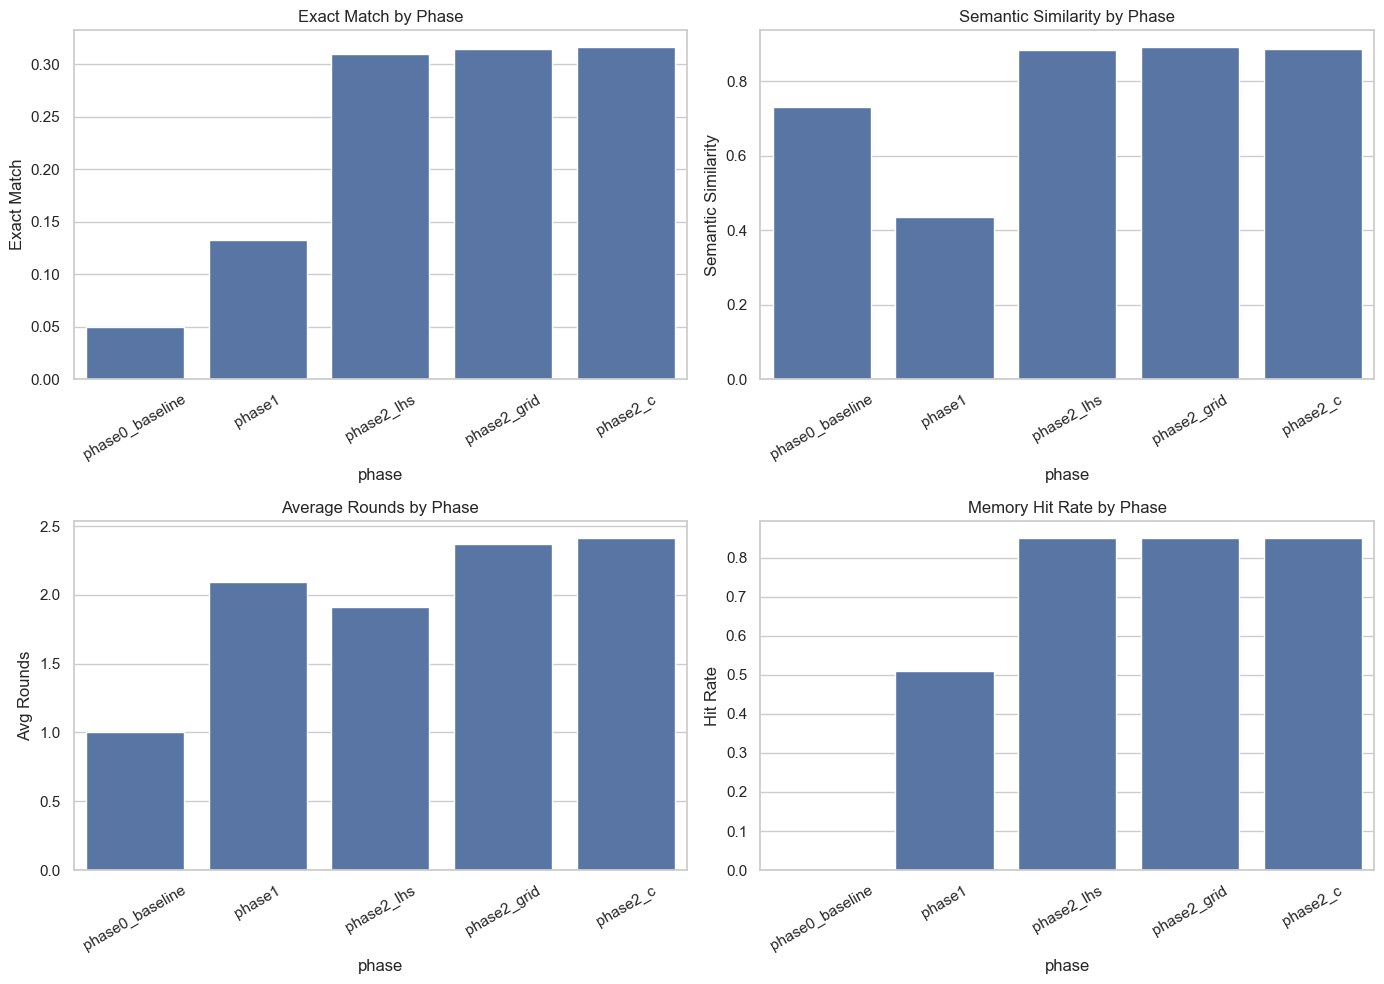

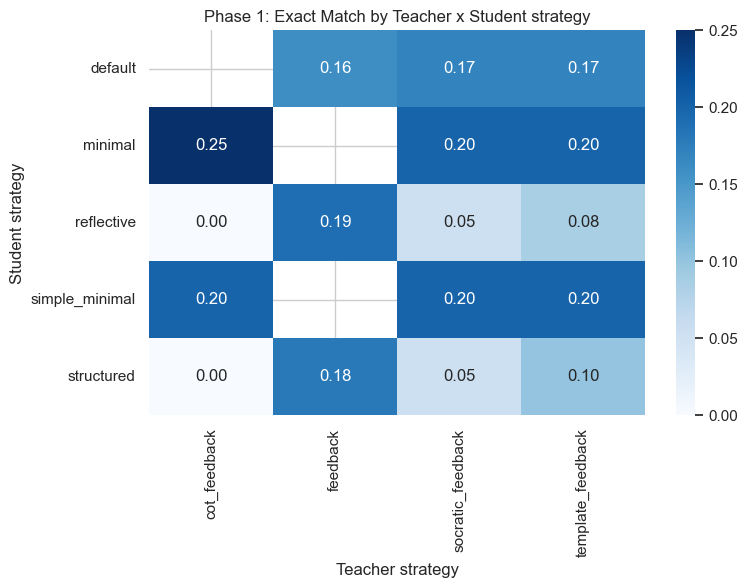

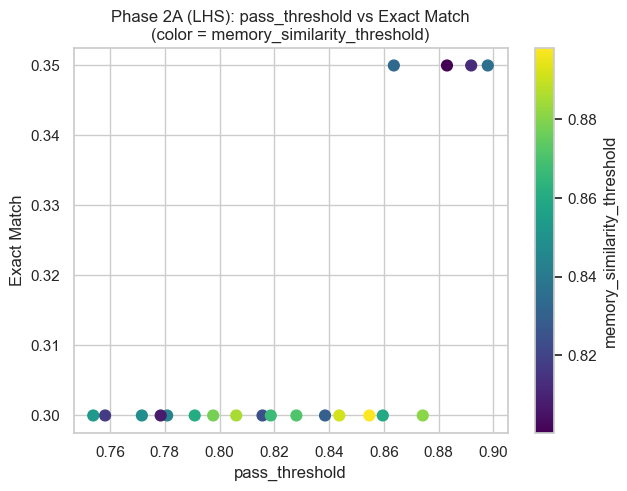

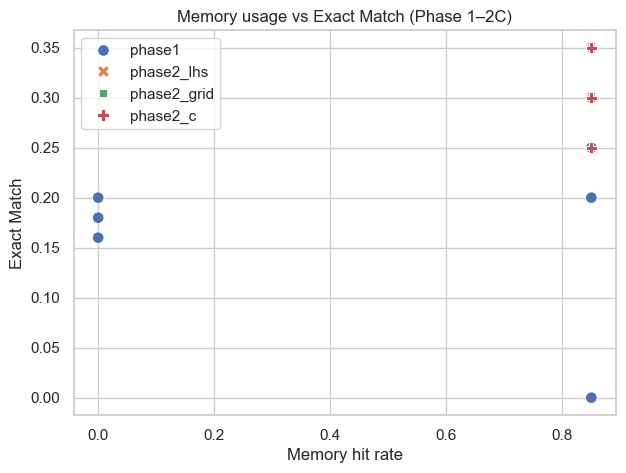

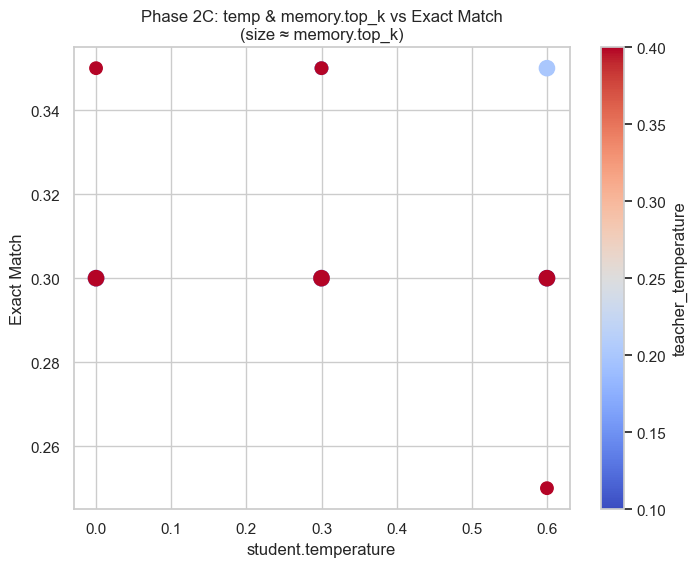

In [19]:
# ==========================================
# VISUALIZATION: Phase 0–2 (รวมถึง 2C)
# ==========================================

from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

log_dir = project_root / "logs" / "experiments" / "hyperparameter_tuning"

# -------- 1) Load Phase 0 baseline (per-question) --------
baseline_files = sorted(log_dir.glob("phase0_baseline_*.jsonl"))
baseline_row = None

if baseline_files:
    metrics_list = []
    for path in baseline_files:
        with path.open("r", encoding="utf-8") as f:
            for line in f:
                rec = json.loads(line)
                s = rec.get("scores", {})
                metrics_list.append({
                    "exact_match": float(s.get("exact_match", 0.0)),
                    "rouge_l": float(s.get("rouge_l", 0.0)),
                    "semantic_similarity": float(s.get("semantic_similarity", 0.0)),
                    "blind_judge": float(s.get("blind_judge", 0.0)),
                    "comparison_judge": float(s.get("comparison_judge", 0.0)),
                })
    if metrics_list:
        df_b0 = pd.DataFrame(metrics_list)
        baseline_row = {
            "phase": "phase0_baseline",
            "experiment_id": "phase0_baseline",
            "teacher": "baseline",
            "student": "baseline",
            "teacher_style": None,
            "exact_match": df_b0["exact_match"].mean(),
            "rouge_l": df_b0["rouge_l"].mean(),
            "semantic_similarity": df_b0["semantic_similarity"].mean(),
            "blind_judge": df_b0["blind_judge"].mean(),
            "comparison_judge": df_b0["comparison_judge"].mean(),
            "avg_rounds": 1.0,
            "memory_hit_rate": 0.0,
            "pass_threshold": None,
            "mem_sim": None,
            "memory_top_k": None,
            "student_temperature": None,
            "teacher_temperature": None,
        }

# -------- 2) Load experiment-level results (Phase 1 / 2A / 2B / 2C) --------
result_files = sorted(log_dir.glob("results_*.jsonl"))

rows = []
for path in result_files:
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            phase = rec.get("phase", "unknown")
            cfg = rec.get("config", {})
            m = rec.get("metrics", {})

            rows.append({
                "phase": phase,
                "experiment_id": rec.get("experiment_id"),
                "teacher": cfg.get("teacher"),
                "student": cfg.get("student"),
                "teacher_style": cfg.get("teacher_style"),
                "exact_match": float(m.get("exact_match", 0.0)),
                "rouge_l": float(m.get("rouge_l", 0.0)),
                "semantic_similarity": float(m.get("semantic_similarity", 0.0)),
                "blind_judge": float(m.get("blind_judge", 0.0)),
                "comparison_judge": float(m.get("comparison_judge", 0.0)),
                "avg_rounds": float(rec.get("avg_rounds", 0.0)),
                "memory_hit_rate": float(cfg.get("memory_hit_rate", 0.0) or 0.0),
                "pass_threshold": cfg.get("pass_threshold"),
                "mem_sim": cfg.get("memory_similarity_threshold"),
                "memory_top_k": cfg.get("memory_top_k"),
                "student_temperature": cfg.get("student_temperature"),
                "teacher_temperature": cfg.get("teacher_temperature"),
            })

df_exp = pd.DataFrame(rows)

# เพิ่ม baseline เข้าไปถ้ามี
if baseline_row is not None:
    df_exp = pd.concat([df_exp, pd.DataFrame([baseline_row])], ignore_index=True)

# -------- 3) Phase summary: 0 / 1 / 2_x / 2C --------
metric_cols = ["exact_match", "semantic_similarity", "blind_judge", "comparison_judge"]
phase_order = ["phase0_baseline", "phase1", "phase2_lhs", "phase2_grid", "phase2_c"]

df_phase_summary = (
    df_exp[df_exp["phase"].notna()]
    .groupby("phase")[metric_cols + ["avg_rounds", "memory_hit_rate"]]
    .mean()
    .reset_index()
)
df_phase_summary["phase"] = pd.Categorical(df_phase_summary["phase"], categories=phase_order, ordered=True)
df_phase_summary = df_phase_summary.sort_values("phase")

print("Phase summary:")
display(df_phase_summary)

# -------- 4) Plot: Phase-level EM / Semantic / Rounds / Memory hit --------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# EM
sns.barplot(
    data=df_phase_summary,
    x="phase",
    y="exact_match",
    ax=axes[0, 0],
    order=phase_order
)
axes[0, 0].set_title("Exact Match by Phase")
axes[0, 0].set_ylabel("Exact Match")
axes[0, 0].tick_params(axis="x", rotation=30)

# Semantic
sns.barplot(
    data=df_phase_summary,
    x="phase",
    y="semantic_similarity",
    ax=axes[0, 1],
    order=phase_order
)
axes[0, 1].set_title("Semantic Similarity by Phase")
axes[0, 1].set_ylabel("Semantic Similarity")
axes[0, 1].tick_params(axis="x", rotation=30)

# Avg rounds
sns.barplot(
    data=df_phase_summary,
    x="phase",
    y="avg_rounds",
    ax=axes[1, 0],
    order=phase_order
)
axes[1, 0].set_title("Average Rounds by Phase")
axes[1, 0].set_ylabel("Avg Rounds")
axes[1, 0].tick_params(axis="x", rotation=30)

# Memory hit rate
sns.barplot(
    data=df_phase_summary,
    x="phase",
    y="memory_hit_rate",
    ax=axes[1, 1],
    order=phase_order
)
axes[1, 1].set_title("Memory Hit Rate by Phase")
axes[1, 1].set_ylabel("Hit Rate")
axes[1, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# -------- 5) Phase 1: Teacher x Student heatmap (Exact Match) --------
df_phase1 = df_exp[df_exp["phase"] == "phase1"].copy()
if not df_phase1.empty:
    pivot_em = df_phase1.pivot_table(
        index="student",
        columns="teacher",
        values="exact_match",
        aggfunc="mean",
    )

    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot_em, annot=True, fmt=".2f", cmap="Blues")
    plt.title("Phase 1: Exact Match by Teacher x Student strategy")
    plt.xlabel("Teacher strategy")
    plt.ylabel("Student strategy")
    plt.show()

# -------- 6) Phase 2A: pass_threshold vs EM (color = mem_sim) --------
df_lhs = df_exp[df_exp["phase"] == "phase2_lhs"].copy()
if not df_lhs.empty:
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(
        df_lhs["pass_threshold"],
        df_lhs["exact_match"],
        c=df_lhs["mem_sim"],
        cmap="viridis",
        s=60,
    )
    plt.colorbar(sc, label="memory_similarity_threshold")
    plt.xlabel("pass_threshold")
    plt.ylabel("Exact Match")
    plt.title("Phase 2A (LHS): pass_threshold vs Exact Match\n(color = memory_similarity_threshold)")
    plt.show()

# -------- 7) Memory hit rate vs Exact Match (Phase 1–2C) --------
df_mem = df_exp[df_exp["phase"].isin(["phase1", "phase2_lhs", "phase2_grid", "phase2_c"])].copy()
if not df_mem.empty:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df_mem,
        x="memory_hit_rate",
        y="exact_match",
        hue="phase",
        style="phase",
        s=70,
    )
    plt.xlabel("Memory hit rate")
    plt.ylabel("Exact Match")
    plt.title("Memory usage vs Exact Match (Phase 1–2C)")
    plt.legend()
    plt.show()

# -------- 8) Phase 2C: temp + top_k vs Exact Match --------
df_2c = df_exp[df_exp["phase"] == "phase2_c"].copy()
if not df_2c.empty:
    # Scatter: student_temp vs exact_match, color = teacher_temp, size = top_k
    plt.figure(figsize=(8, 6))
    sizes = 50 if df_2c["memory_top_k"].isna().all() else 40 + 20 * (df_2c["memory_top_k"] - df_2c["memory_top_k"].min())
    sc = plt.scatter(
        df_2c["student_temperature"],
        df_2c["exact_match"],
        c=df_2c["teacher_temperature"],
        s=sizes,
        cmap="coolwarm",
    )
    plt.colorbar(sc, label="teacher_temperature")
    plt.xlabel("student.temperature")
    plt.ylabel("Exact Match")
    plt.title("Phase 2C: temp & memory.top_k vs Exact Match\n(size ≈ memory.top_k)")
    plt.show()


## Phase 3: Judge Analysis

Test different judge variants (strict/current/lenient) to find optimal evaluation strategy.

In [20]:
# ==========================================
# PHASE 3: Judge & Metric Consistency
# ==========================================

from pathlib import Path
import json

exp_dir = project_root / "logs" / "experiments" / "hyperparameter_tuning"

# 1) โหลด champion config จาก Phase 2C (ดีที่สุดจากไฟล์จริง)
phase2c_records = []
for p in exp_dir.glob("results_*.jsonl"):
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            if rec.get("phase") == "phase2_c":
                phase2c_records.append(rec)

if not phase2c_records:
    print("No Phase 2C results found. Please run Phase 2C first.")
else:
    # เลือกตัวที่ exact_match สูงสุดจาก Phase 2C
    best_2c = max(phase2c_records, key=lambda r: r["metrics"]["exact_match"])
    champ_cfg = best_2c["config"]
    champ_metrics = best_2c["metrics"]

    print("="*80)
    print("PHASE 3 BASE (Champion config from Phase 2C)")
    print("="*80)
    print("Experiment:", best_2c["experiment_id"])
    print("Exact Match:", champ_metrics["exact_match"])
    print("ROUGE-L:    ", champ_metrics["rouge_l"])
    print("Semantic:   ", champ_metrics["semantic_similarity"])
    print("BlindJudge: ", champ_metrics["blind_judge"])
    print("CompJudge:  ", champ_metrics["comparison_judge"])
    print()
    print("Config:")
    print("  teacher:", champ_cfg["teacher"])
    print("  student:", champ_cfg["student"])
    print("  pass_threshold:", champ_cfg["pass_threshold"])
    print("  metric_weights:", champ_cfg["metric_weights"])
    print("  memory_similarity_threshold:", champ_cfg["memory_similarity_threshold"])
    print("  memory_top_k:", champ_cfg.get("memory_top_k"))
    print("  student_temperature:", champ_cfg.get("student_temperature"))
    print("  teacher_temperature:", champ_cfg.get("teacher_temperature"))

    # 2) สร้าง judge variants
    judge_variants = [
        {
            "name": "full_hybrid",
            "overrides": {
                # ใช้ weights champion ตามเดิม
                # hybrid_scoring.enabled ตาม config base_config (ไม่ override)
            },
        },
        {
            "name": "blind_only",
            "overrides": {
                "teacher.hybrid_scoring.enabled": True,
                "teacher.metrics.weights.blind_score": 1.0,
                "teacher.metrics.weights.comparison_score": 0.0,
                "teacher.metrics.weights.semantic_sim": 0.0,
                "teacher.metrics.weights.rouge_l": 0.0,
                "teacher.metrics.weights.exact_match": 0.0,
            },
        },
        {
            "name": "comparison_only",
            "overrides": {
                "teacher.hybrid_scoring.enabled": True,
                "teacher.metrics.weights.blind_score": 0.0,
                "teacher.metrics.weights.comparison_score": 1.0,
                "teacher.metrics.weights.semantic_sim": 0.0,
                "teacher.metrics.weights.rouge_l": 0.0,
                "teacher.metrics.weights.exact_match": 0.0,
            },
        },
        {
            "name": "deterministic_only",
            "overrides": {
                "teacher.hybrid_scoring.enabled": False,
                "teacher.metrics.weights.blind_score": 0.0,
                "teacher.metrics.weights.comparison_score": 0.0,
                "teacher.metrics.weights.semantic_sim": 0.8,
                "teacher.metrics.weights.rouge_l": 0.15,
                "teacher.metrics.weights.exact_match": 0.05,
            },
        },
    ]

    phase3_results = []
    phase3_tracker = ExperimentTracker()

    # dataset สำหรับ Phase 3 (ใช้ชุดเดียวกับ Phase 2 ตอนนี้)
    phase3_dataset = phase2_dataset  # หรือเปลี่ยนเป็นชุดใหญ่ขึ้นได้ในอนาคต

    for variant in judge_variants:
        name = variant["name"]
        judge_overrides = variant["overrides"]

        # common overrides จาก champion config
        common_overrides = {
            "teacher.pass_threshold": champ_cfg["pass_threshold"],
            "teacher.metrics.weights.blind_score": champ_cfg["metric_weights"]["blind_score"],
            "teacher.metrics.weights.comparison_score": champ_cfg["metric_weights"]["comparison_score"],
            "teacher.metrics.weights.semantic_sim": champ_cfg["metric_weights"]["semantic_sim"],
            "teacher.metrics.weights.rouge_l": champ_cfg["metric_weights"]["rouge_l"],
            "teacher.metrics.weights.exact_match": champ_cfg["metric_weights"]["exact_match"],
            "memory.similarity_threshold": champ_cfg["memory_similarity_threshold"],
            "memory.top_k": champ_cfg.get("memory_top_k", base_config["memory"]["top_k"]),
            "student.temperature": champ_cfg.get("student_temperature", base_config["student"]["temperature"]),
            "teacher.temperature": champ_cfg.get("teacher_temperature", base_config["teacher"]["temperature"]),
        }

        # ถ้าเป็น full_hybrid ไม่ override weights → ใช้ common อย่างเดียว
        if name == "full_hybrid":
            final_overrides = common_overrides
        else:
            final_overrides = dict(common_overrides)
            final_overrides.update(judge_overrides)

        print("\n" + "="*60)
        print(f"[PHASE 3] Judge mode: {name}")
        print("="*60)

        start_time = time.time()
        try:
            result = run_phase2_config(
                config_overrides=final_overrides,
                dataset=phase3_dataset,
                base_config=base_config,
                teacher_key=champ_cfg["teacher"],
                student_first_key=best_student_first,   # จาก Phase 2 setup
                student_refine_key=best_student_refine, # จาก Phase 2 setup
                max_rounds=3,
            )
            elapsed = time.time() - start_time

            cfg_for_tracker = {
                "teacher": champ_cfg["teacher"],
                "student": champ_cfg["student"],
                "judge_mode": name,
                "pass_threshold": final_overrides["teacher.pass_threshold"],
                "metric_weights": {
                    "blind_score": final_overrides["teacher.metrics.weights.blind_score"],
                    "comparison_score": final_overrides["teacher.metrics.weights.comparison_score"],
                    "semantic_sim": final_overrides["teacher.metrics.weights.semantic_sim"],
                    "rouge_l": final_overrides["teacher.metrics.weights.rouge_l"],
                    "exact_match": final_overrides["teacher.metrics.weights.exact_match"],
                },
                "memory_similarity_threshold": final_overrides["memory.similarity_threshold"],
                "memory_top_k": final_overrides["memory.top_k"],
                "student_temperature": final_overrides["student.temperature"],
                "teacher_temperature": final_overrides["teacher.temperature"],
                "max_rounds": 3,
                "memory_hits": result["memory_hits"],
                "memory_hit_rate": result["memory_hit_rate"],
            }

            exp_result = ExperimentResult(
                experiment_id=f"phase3_judge_{name}",
                phase="phase3_judge",
                config=cfg_for_tracker,
                metrics=result["metrics"],
                avg_rounds=result["avg_rounds"],
                total_tokens=0,
                cost=0.0,
                timestamp=datetime.now().isoformat(),
            )
            phase3_tracker.add_result(exp_result)

            phase3_results.append({
                "judge_mode": name,
                "config": cfg_for_tracker,
                "metrics": result["metrics"],
                "avg_rounds": result["avg_rounds"],
            })

            print("\n📊 Metrics:")
            print(f"  Exact Match: {result['metrics']['exact_match']:.3f}")
            print(f"  ROUGE-L:     {result['metrics']['rouge_l']:.3f}")
            print(f"  Semantic:    {result['metrics']['semantic_similarity']:.3f}")
            print(f"  BlindJudge:  {result['metrics']['blind_judge']:.3f}")
            print(f"  CompJudge:   {result['metrics']['comparison_judge']:.3f}")
            print(f"  Avg Rounds:  {result['avg_rounds']:.2f}")
            print(f"  Memory Hits: {result['memory_hits']}/{result['total_questions']} "
                  f"({result['memory_hit_rate']*100:.1f}%)")
            print(f"  Time:        {elapsed:.1f}s ({elapsed/60:.1f} min)")

            phase3_tracker.save()
        except Exception as e:
            print(f"\n❌ ERROR in Phase 3 judge mode '{name}': {e}")
            import traceback
            traceback.print_exc()
            continue

    print("\n" + "="*80)
    print("PHASE 3 (Judge Consistency) COMPLETE")
    print("="*80)


PHASE 3 BASE (Champion config from Phase 2C)
Experiment: phase2_c_4
Exact Match: 0.35
ROUGE-L:     0.6930180768295526
Semantic:    0.9082406371831894
BlindJudge:  0.8625000000000002
CompJudge:   0.925

Config:
  teacher: cot_feedback
  student: minimal
  pass_threshold: 0.8979581727010184
  metric_weights: {'blind_score': 0.24248502134532077, 'comparison_score': 0.39333727855547485, 'semantic_sim': 0.2141777000992044, 'rouge_l': 0.1, 'exact_match': 0.05}
  memory_similarity_threshold: 0.8356312485568045
  memory_top_k: 3
  student_temperature: 0.0
  teacher_temperature: 0.2

[PHASE 3] Judge mode: full_hybrid
2025-11-18 03:15:48,834 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-11-18 03:15:48,834 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-18 03:15:48,844 | INFO     | provider.ratelimit                  | RateLimiter init

## Phase 4: Cross-Domain Testing

Test model generalization across domains.
Note: Simplified version - full transfer learning requires memory persistence mechanism.

In [25]:
# Patch FAISSMemory.search at runtime เพื่อกัน k <= 0
from src.simplified.memory import FAISSMemory

def _patched_search(self, question: str, k=None):
    # ใช้ค่า default จาก config ถ้าไม่ได้ส่ง k มา
    if k is None:
        k = self.top_k

    # ถ้า top_k <= 0 หรือ index ยังว่าง → treat เป็น "memory ปิด"
    # ตรงนี้กันไม่ให้เรียก faiss.search ด้วย k=0
    if k <= 0 or self.index.ntotal == 0:
        return []

    # จากตรงนี้ลงไปเหมือน implementation เดิม
    query_emb = self._compute_embedding(question)

    scores, indices = self.index.search(
        query_emb.reshape(1, -1),
        min(k, self.index.ntotal),
    )

    results = []
    for idx, score in zip(indices[0], scores[0]):
        if 0 <= idx < len(self._ids):
            record_id = self._ids[idx]
            results.append((record_id, float(score)))
    return results

FAISSMemory.search = _patched_search
print("Patched FAISSMemory.search (k<=0 now returns []).")


Patched FAISSMemory.search (k<=0 now returns []).


In [26]:
# PHASE 4: Final Evaluation (100Q/domain) + Memory Ablation
# ========================================================

import os
from pathlib import Path

print("=" * 80)
print("PHASE 4: Final evaluation (100Q/domain) + memory ablation")
print("=" * 80)

# --------------------------------------------------------------------
# 1) Load 100-question datasets per domain
# --------------------------------------------------------------------
alpaca_100 = load_dataset(str(project_root / 'data' / 'alpaca_100.jsonl'), max_samples=100)
medical_100 = load_dataset(str(project_root / 'data' / 'medical_100.jsonl'), max_samples=100)

domains_phase4 = {
    "alpaca": alpaca_100,
    "medical": medical_100,
}

print("Loaded Phase 4 datasets:")
for name, data in domains_phase4.items():
    print(f"  {name}: {len(data)} questions")

# --------------------------------------------------------------------
# 2) Reload champion config from Phase 2C results (real logs)
# --------------------------------------------------------------------
exp_dir = project_root / "logs" / "experiments" / "hyperparameter_tuning"

phase2c_records = []
for p in exp_dir.glob("results_*.jsonl"):
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            if rec.get("phase") == "phase2_c":
                phase2c_records.append(rec)

if not phase2c_records:
    raise RuntimeError("No Phase 2C results found. Please run Phase 2C before Phase 4.")

best_2c = max(phase2c_records, key=lambda r: r["metrics"]["exact_match"])
champ_cfg = best_2c["config"]
champ_metrics = best_2c["metrics"]

print("\n" + "=" * 80)
print("Phase 4 base config (Champion from Phase 2C)")
print("=" * 80)
print("Experiment:", best_2c["experiment_id"])
print("Exact Match:", champ_metrics["exact_match"])
print("ROUGE-L:    ", champ_metrics["rouge_l"])
print("Semantic:   ", champ_metrics["semantic_similarity"])
print("BlindJudge: ", champ_metrics["blind_judge"])
print("CompJudge:  ", champ_metrics["comparison_judge"])
print()
print("Config:")
print("  teacher:", champ_cfg["teacher"])
print("  student:", champ_cfg["student"])
print("  pass_threshold:", champ_cfg["pass_threshold"])
print("  metric_weights:", champ_cfg["metric_weights"])
print("  memory_similarity_threshold:", champ_cfg["memory_similarity_threshold"])
print("  memory_top_k:", champ_cfg.get("memory_top_k"))
print("  student_temperature:", champ_cfg.get("student_temperature"))
print("  teacher_temperature:", champ_cfg.get("teacher_temperature"))

# --------------------------------------------------------------------
# 3) Helper: build overrides for champion config (memory ON/OFF)
# --------------------------------------------------------------------
def build_champion_overrides(memory_top_k: int,
                             memory_suffix: str,
                             use_hybrid: bool = True) -> Dict[str, Any]:
    """
    Build override dict for champion config, with per-run memory paths.
    memory_suffix ใช้แยกไฟล์ memory ของแต่ละการทดลอง เพื่อให้เริ่มจาก memory ว่าง
    """
    mem_storage = project_root / "logs" / "simplified" / f"phase4_memory_{memory_suffix}.jsonl"
    mem_index = project_root / "logs" / "simplified" / f"phase4_memory_{memory_suffix}.index"

    overrides = {
        "teacher.pass_threshold": champ_cfg["pass_threshold"],
        "teacher.metrics.weights.blind_score": champ_cfg["metric_weights"]["blind_score"],
        "teacher.metrics.weights.comparison_score": champ_cfg["metric_weights"]["comparison_score"],
        "teacher.metrics.weights.semantic_sim": champ_cfg["metric_weights"]["semantic_sim"],
        "teacher.metrics.weights.rouge_l": champ_cfg["metric_weights"]["rouge_l"],
        "teacher.metrics.weights.exact_match": champ_cfg["metric_weights"]["exact_match"],
        "memory.similarity_threshold": champ_cfg["memory_similarity_threshold"],
        "memory.top_k": memory_top_k,
        "memory.storage_path": str(mem_storage),
        "memory.index_path": str(mem_index),
        "student.temperature": champ_cfg.get("student_temperature", base_config["student"]["temperature"]),
        "teacher.temperature": champ_cfg.get("teacher_temperature", base_config["teacher"]["temperature"]),
        "loop.max_rounds": 3,
    }

    # เปิด/ปิด hybrid scoring (สอง judge) ตามที่ต้องการ
    overrides["teacher.hybrid_scoring.enabled"] = bool(use_hybrid)

    return overrides

# --------------------------------------------------------------------
# 4) Run Phase 4 experiments:
#    - baseline (student only)
#    - champion + memory ON  (comparison_only judge policy)
#    - champion + memory OFF (comparison_only judge policy)
# --------------------------------------------------------------------
phase4_results: List[Dict[str, Any]] = []
phase4_tracker = ExperimentTracker()

print("\n" + "=" * 80)
print("Running Phase 4 experiments per domain")
print("=" * 80)

for domain_name, dataset in domains_phase4.items():
    print(f"\n--- Domain: {domain_name} ---")
    print(f"Questions: {len(dataset)}")

    # 4.1 Baseline (student only, no teacher/memory)
    if "run_baseline" in globals():
        print("\n[Phase 4] Baseline (student only)")
        baseline_metrics, baseline_tokens, baseline_detail = run_baseline(dataset, base_config)

        cfg_baseline = {
            "domain": domain_name,
            "mode": "baseline",
        }

        exp_baseline = ExperimentResult(
            experiment_id=f"phase4_baseline_{domain_name}",
            phase="phase4",
            config=cfg_baseline,
            metrics=baseline_metrics,
            avg_rounds=1.0,          # baseline มี 1 รอบเสมอ
            total_tokens=baseline_tokens,
            cost=0.0,                # ถ้าจะคิดค่าใช้จ่ายจริงค่อยเติมภายหลัง
            timestamp=datetime.now().isoformat(),
        )
        phase4_tracker.add_result(exp_baseline)

        phase4_results.append({
            "domain": domain_name,
            "mode": "baseline",
            "metrics": baseline_metrics,
            "avg_rounds": 1.0,
            "memory_hits": None,
            "memory_hit_rate": None,
        })

        print("  Baseline Exact Match:", baseline_metrics["exact_match"])
        print("  Baseline Semantic:    ", baseline_metrics["semantic_similarity"])
    else:
        print("\n[Phase 4] Skipping baseline: run_baseline is not defined in this kernel")

    # 4.2 Champion config + memory ON + comparison_only judge rule
    print("\n[Phase 4] Champion (memory ON, comparison_only judge)")
    overrides_mem_on = build_champion_overrides(
        memory_top_k=champ_cfg.get("memory_top_k", base_config["memory"]["top_k"]),
        memory_suffix=f"{domain_name}_mem_on",
        use_hybrid=True,   # ใช้ hybrid scoring (2 judge) ใน config
    )

    # policy comparison_only:
    overrides_mem_on.update({
        "teacher.hybrid_scoring.enabled": True,
        "teacher.metrics.weights.blind_score": 0.0,
        "teacher.metrics.weights.comparison_score": 1.0,
        "teacher.metrics.weights.semantic_sim": 0.0,
        "teacher.metrics.weights.rouge_l": 0.0,
        "teacher.metrics.weights.exact_match": 0.0,
    })

    start_time = time.time()
    result_mem_on = run_phase2_config(
        config_overrides=overrides_mem_on,
        dataset=dataset,
        base_config=base_config,
        teacher_key=champ_cfg["teacher"],
        student_first_key=best_student_first,
        student_refine_key=best_student_refine,
        max_rounds=3,
    )
    elapsed_on = time.time() - start_time

    cfg_mem_on = {
        "domain": domain_name,
        "mode": "champion_mem_on",
        "teacher": champ_cfg["teacher"],
        "student": champ_cfg["student"],
        "pass_threshold": overrides_mem_on["teacher.pass_threshold"],
        "metric_weights": {
            "blind_score": overrides_mem_on["teacher.metrics.weights.blind_score"],
            "comparison_score": overrides_mem_on["teacher.metrics.weights.comparison_score"],
            "semantic_sim": overrides_mem_on["teacher.metrics.weights.semantic_sim"],
            "rouge_l": overrides_mem_on["teacher.metrics.weights.rouge_l"],
            "exact_match": overrides_mem_on["teacher.metrics.weights.exact_match"],
        },
        "memory_similarity_threshold": overrides_mem_on["memory.similarity_threshold"],
        "memory_top_k": overrides_mem_on["memory.top_k"],
        "student_temperature": overrides_mem_on["student.temperature"],
        "teacher_temperature": overrides_mem_on["teacher.temperature"],
        "max_rounds": 3,
    }

    exp_mem_on = ExperimentResult(
        experiment_id=f"phase4_champion_mem_on_{domain_name}",
        phase="phase4",
        config=cfg_mem_on,
        metrics=result_mem_on["metrics"],
        avg_rounds=result_mem_on["avg_rounds"],
        total_tokens=0,
        cost=0.0,
        timestamp=datetime.now().isoformat(),
    )
    phase4_tracker.add_result(exp_mem_on)

    phase4_results.append({
        "domain": domain_name,
        "mode": "champion_mem_on",
        "metrics": result_mem_on["metrics"],
        "avg_rounds": result_mem_on["avg_rounds"],
        "memory_hits": result_mem_on["memory_hits"],
        "memory_hit_rate": result_mem_on["memory_hit_rate"],
    })

    print("  EM:", result_mem_on["metrics"]["exact_match"])
    print("  Semantic:", result_mem_on["metrics"]["semantic_similarity"])
    print("  Avg Rounds:", result_mem_on["avg_rounds"])
    print("  Memory Hits:", result_mem_on["memory_hits"])
    print(f"  Time: {elapsed_on/60:.1f} min")

    # 4.3 Champion config + memory OFF (top_k = 0) + comparison_only judge
    print("\n[Phase 4] Champion (memory OFF, comparison_only judge)")
    overrides_mem_off = build_champion_overrides(
        memory_top_k=0,
        memory_suffix=f"{domain_name}_mem_off",
        use_hybrid=True,
    )

    overrides_mem_off.update({
        "teacher.hybrid_scoring.enabled": True,
        "teacher.metrics.weights.blind_score": 0.0,
        "teacher.metrics.weights.comparison_score": 1.0,
        "teacher.metrics.weights.semantic_sim": 0.0,
        "teacher.metrics.weights.rouge_l": 0.0,
        "teacher.metrics.weights.exact_match": 0.0,
        "memory.similarity_threshold": 0.99,  # กันไม่ให้ retrieval ง่ายเกินไป
    })

    start_time = time.time()
    result_mem_off = run_phase2_config(
        config_overrides=overrides_mem_off,
        dataset=dataset,
        base_config=base_config,
        teacher_key=champ_cfg["teacher"],
        student_first_key=best_student_first,
        student_refine_key=best_student_refine,
        max_rounds=3,
    )
    elapsed_off = time.time() - start_time

    cfg_mem_off = {
        "domain": domain_name,
        "mode": "champion_mem_off",
        "teacher": champ_cfg["teacher"],
        "student": champ_cfg["student"],
        "pass_threshold": overrides_mem_off["teacher.pass_threshold"],
        "metric_weights": {
            "blind_score": overrides_mem_off["teacher.metrics.weights.blind_score"],
            "comparison_score": overrides_mem_off["teacher.metrics.weights.comparison_score"],
            "semantic_sim": overrides_mem_off["teacher.metrics.weights.semantic_sim"],
            "rouge_l": overrides_mem_off["teacher.metrics.weights.rouge_l"],
            "exact_match": overrides_mem_off["teacher.metrics.weights.exact_match"],
        },
        "memory_similarity_threshold": overrides_mem_off["memory.similarity_threshold"],
        "memory_top_k": overrides_mem_off["memory.top_k"],
        "student_temperature": overrides_mem_off["student.temperature"],
        "teacher_temperature": overrides_mem_off["teacher.temperature"],
        "max_rounds": 3,
    }

    exp_mem_off = ExperimentResult(
        experiment_id=f"phase4_champion_mem_off_{domain_name}",
        phase="phase4",
        config=cfg_mem_off,
        metrics=result_mem_off["metrics"],
        avg_rounds=result_mem_off["avg_rounds"],
        total_tokens=0,
        cost=0.0,
        timestamp=datetime.now().isoformat(),
    )
    phase4_tracker.add_result(exp_mem_off)

    phase4_results.append({
        "domain": domain_name,
        "mode": "champion_mem_off",
        "metrics": result_mem_off["metrics"],
        "avg_rounds": result_mem_off["avg_rounds"],
        "memory_hits": result_mem_off["memory_hits"],
        "memory_hit_rate": result_mem_off["memory_hit_rate"],
    })

    print("  EM:", result_mem_off["metrics"]["exact_match"])
    print("  Semantic:", result_mem_off["metrics"]["semantic_similarity"])
    print("  Avg Rounds:", result_mem_off["avg_rounds"])
    print("  Memory Hits:", result_mem_off["memory_hits"])
    print(f"  Time: {elapsed_off/60:.1f} min")

# Save Phase 4 results to separate file
phase4_tracker.save()

print("\n" + "=" * 80)
print("PHASE 4 COMPLETE")
print("=" * 80)


PHASE 4: Final evaluation (100Q/domain) + memory ablation
Loaded Phase 4 datasets:
  alpaca: 100 questions
  medical: 100 questions

Phase 4 base config (Champion from Phase 2C)
Experiment: phase2_c_4
Exact Match: 0.35
ROUGE-L:     0.6930180768295526
Semantic:    0.9082406371831894
BlindJudge:  0.8625000000000002
CompJudge:   0.925

Config:
  teacher: cot_feedback
  student: minimal
  pass_threshold: 0.8979581727010184
  metric_weights: {'blind_score': 0.24248502134532077, 'comparison_score': 0.39333727855547485, 'semantic_sim': 0.2141777000992044, 'rouge_l': 0.1, 'exact_match': 0.05}
  memory_similarity_threshold: 0.8356312485568045
  memory_top_k: 3
  student_temperature: 0.0
  teacher_temperature: 0.2

Running Phase 4 experiments per domain

--- Domain: alpaca ---
Questions: 100

[Phase 4] Skipping baseline: run_baseline is not defined in this kernel

[Phase 4] Champion (memory ON, comparison_only judge)
2025-11-18 11:09:41,872 | INFO     | provider.ratelimit                  | Rate

PHASE 4 ANALYSIS

Phase 4 summary table:


,domain,mode,exact_match,rouge_l,semantic_similarity,blind_judge,comparison_judge,avg_rounds,memory_hit_rate
0,alpaca,champion_mem_on,0.07,0.534407,0.731712,0.8770,0.942,1.13,0.14
1,alpaca,champion_mem_off,0.04,0.509401,0.725059,0.8765,0.938,1.23,0.00
2,medical,champion_mem_on,0.01,0.356149,0.704773,0.8725,0.897,1.25,0.01
3,medical,champion_mem_off,0.01,0.368681,0.709626,0.8725,0.902,1.27,0.00



Aggregated metrics by domain/mode:


,domain,mode,exact_match,rouge_l,semantic_similarity,blind_judge,comparison_judge,avg_rounds,memory_hit_rate
0,alpaca,champion_mem_off,0.04,0.509401,0.725059,0.8765,0.938,1.23,0.00
1,alpaca,champion_mem_on,0.07,0.534407,0.731712,0.8770,0.942,1.13,0.14
2,medical,champion_mem_off,0.01,0.368681,0.709626,0.8725,0.902,1.27,0.00
3,medical,champion_mem_on,0.01,0.356149,0.704773,0.8725,0.897,1.25,0.01


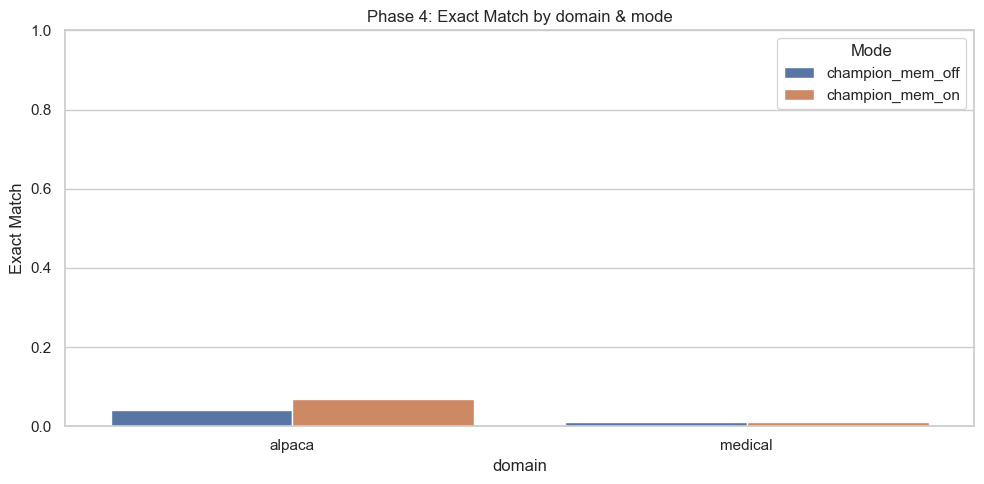

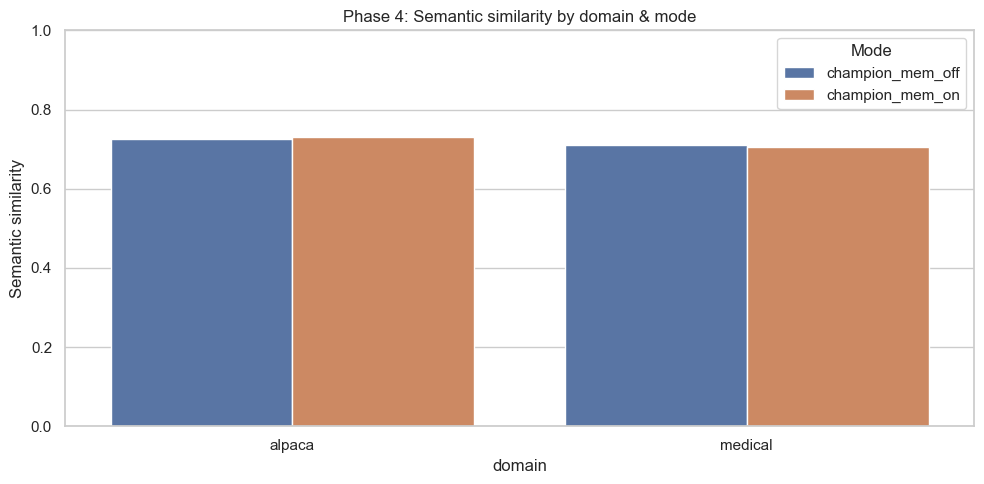

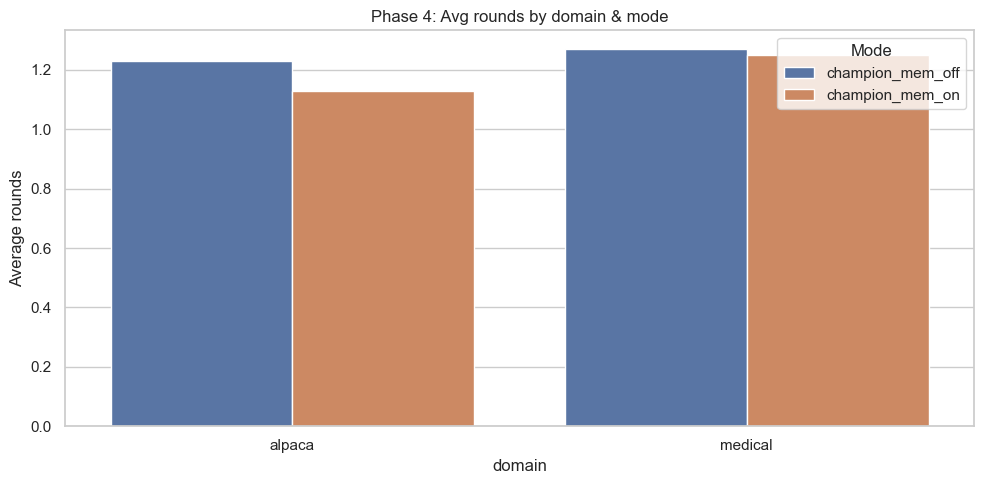

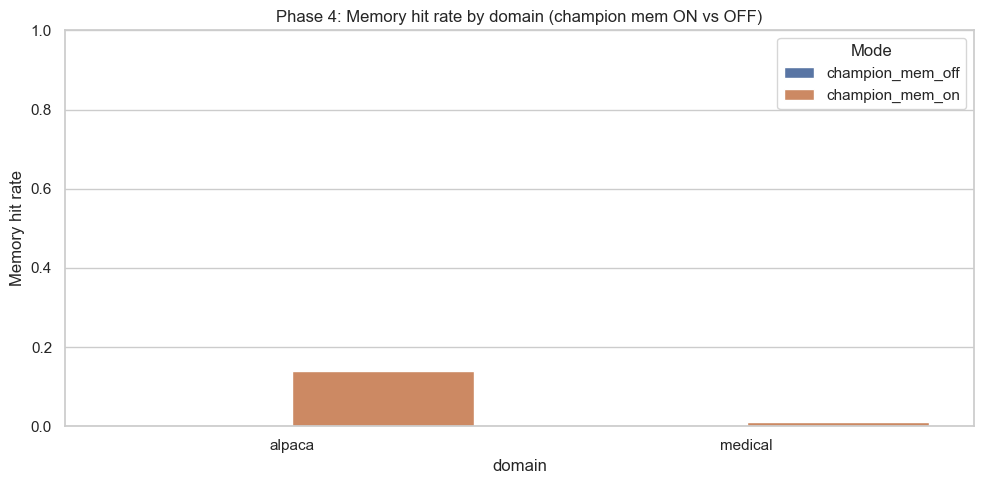


Memory effect (champion_mem_on - champion_mem_off)

Domain: alpaca
  EM   mem_on=0.070 vs mem_off=0.040 (Δ=+0.030)
  Sem  mem_on=0.732 vs mem_off=0.725 (Δ=+0.007)
  Rnds mem_on=1.13 vs mem_off=1.23 (Δ=-0.10)

Domain: medical
  EM   mem_on=0.010 vs mem_off=0.010 (Δ=+0.000)
  Sem  mem_on=0.705 vs mem_off=0.710 (Δ=-0.005)
  Rnds mem_on=1.25 vs mem_off=1.27 (Δ=-0.02)

Phase 4 analysis complete.


In [27]:
# PHASE 4 ANALYSIS: Compare baseline vs champion (mem ON/OFF)
# ==========================================================

import pandas as pd

print("=" * 80)
print("PHASE 4 ANALYSIS")
print("=" * 80)

# เตรียม DataFrame จาก phase4_results
rows = []
for r in phase4_results:
    m = r["metrics"]
    rows.append({
        "domain": r["domain"],
        "mode": r["mode"],
        "exact_match": m["exact_match"],
        "rouge_l": m["rouge_l"],
        "semantic_similarity": m["semantic_similarity"],
        "blind_judge": m.get("blind_judge", float("nan")),
        "comparison_judge": m.get("comparison_judge", float("nan")),
        "avg_rounds": r["avg_rounds"],
        "memory_hit_rate": r.get("memory_hit_rate", float("nan")),
    })

df_phase4 = pd.DataFrame(rows)
print("\nPhase 4 summary table:")
display(df_phase4)

# ----------------------------------------------------------
# 1) สรุปค่าเฉลี่ยต่อ domain/mode ─ ใช้ดูภาพรวม
# ----------------------------------------------------------
summary = (
    df_phase4
    .groupby(["domain", "mode"])
    .agg({
        "exact_match": "mean",
        "rouge_l": "mean",
        "semantic_similarity": "mean",
        "blind_judge": "mean",
        "comparison_judge": "mean",
        "avg_rounds": "mean",
        "memory_hit_rate": "mean",
    })
    .reset_index()
)

print("\nAggregated metrics by domain/mode:")
display(summary)

# ----------------------------------------------------------
# 2) กราฟเปรียบเทียบ EM และ Semantic (per domain & mode)
# ----------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(
    data=summary,
    x="domain",
    y="exact_match",
    hue="mode",
)
plt.title("Phase 4: Exact Match by domain & mode")
plt.ylim(0, 1)
plt.ylabel("Exact Match")
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=summary,
    x="domain",
    y="semantic_similarity",
    hue="mode",
)
plt.title("Phase 4: Semantic similarity by domain & mode")
plt.ylim(0, 1)
plt.ylabel("Semantic similarity")
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 3) กราฟ avg_rounds (ดู cost/รอบ) + memory_hit_rate
# ----------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.barplot(
    data=summary,
    x="domain",
    y="avg_rounds",
    hue="mode",
)
plt.title("Phase 4: Avg rounds by domain & mode")
plt.ylabel("Average rounds")
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=summary[
        summary["mode"] != "baseline"  # baseline ไม่มี memory
    ],
    x="domain",
    y="memory_hit_rate",
    hue="mode",
)
plt.title("Phase 4: Memory hit rate by domain (champion mem ON vs OFF)")
plt.ylabel("Memory hit rate")
plt.ylim(0, 1)
plt.legend(title="Mode")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 4) วิเคราะห์เชิงตัวเลข: memory ช่วยแค่ไหน?
# ----------------------------------------------------------
print("\n" + "=" * 80)
print("Memory effect (champion_mem_on - champion_mem_off)")
print("=" * 80)

mem_on = summary[summary["mode"] == "champion_mem_on"].set_index("domain")
mem_off = summary[summary["mode"] == "champion_mem_off"].set_index("domain")

domains = sorted(set(mem_on.index) & set(mem_off.index))
for d in domains:
    em_on = mem_on.loc[d, "exact_match"]
    em_off = mem_off.loc[d, "exact_match"]
    sem_on = mem_on.loc[d, "semantic_similarity"]
    sem_off = mem_off.loc[d, "semantic_similarity"]
    rounds_on = mem_on.loc[d, "avg_rounds"]
    rounds_off = mem_off.loc[d, "avg_rounds"]

    print(f"\nDomain: {d}")
    print(f"  EM   mem_on={em_on:.3f} vs mem_off={em_off:.3f} (Δ={em_on - em_off:+.3f})")
    print(f"  Sem  mem_on={sem_on:.3f} vs mem_off={sem_off:.3f} (Δ={sem_on - sem_off:+.3f})")
    print(f"  Rnds mem_on={rounds_on:.2f} vs mem_off={rounds_off:.2f} (Δ={rounds_on - rounds_off:+.2f})")

print("\n" + "=" * 80)
print("Phase 4 analysis complete.")
print("=" * 80)


In [33]:
# CELL 1: Prepare df_all (summary-level) and df_debug (round-level)

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ---------- df_all: summary-level from results_*.jsonl ----------
exp_dir = project_root / "logs" / "experiments" / "hyperparameter_tuning"

rows = []
for path in exp_dir.glob("results_*.jsonl"):
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if "metrics" not in rec or "config" not in rec:
                continue

            cfg = rec["config"]
            m = rec["metrics"]

            rows.append({
                "experiment_id": rec.get("experiment_id"),
                "phase": rec.get("phase"),
                "teacher": cfg.get("teacher"),
                "student": cfg.get("student"),
                "domain": cfg.get("domain"),
                "mode": cfg.get("mode"),
                "judge_mode": cfg.get("judge_mode"),
                "pass_threshold": cfg.get("pass_threshold"),
                "mem_top_k": cfg.get("memory_top_k"),
                "mem_sim": cfg.get("memory_similarity_threshold"),
                "student_temp": cfg.get("student_temperature"),
                "teacher_temp": cfg.get("teacher_temperature"),
                "exact_match": m.get("exact_match"),
                "rouge_l": m.get("rouge_l"),
                "semantic": m.get("semantic_similarity"),
                "blind": m.get("blind_judge"),
                "comp": m.get("comparison_judge"),
                "avg_rounds": rec.get("avg_rounds"),
            })

df_raw = pd.DataFrame(rows)
print("Loaded raw rows:", df_raw.shape)

def first_not_nan(series):
    for v in series:
        if pd.notna(v):
            return v
    return np.nan

group_cols = ["experiment_id", "phase"]
param_cols = ["teacher", "student", "domain", "mode", "judge_mode",
              "pass_threshold", "mem_top_k", "mem_sim",
              "student_temp", "teacher_temp"]
metric_cols = ["exact_match", "rouge_l", "semantic", "blind", "comp", "avg_rounds"]

agg_dict = {}
for col in param_cols:
    agg_dict[col] = first_not_nan
for col in metric_cols:
    agg_dict[col] = "mean"

df_all = (
    df_raw
    .groupby(group_cols, as_index=False, dropna=False)
    .agg(agg_dict)
)

print("Cleaned df_all shape:", df_all.shape)
display(df_all.head(10))

# ---------- df_debug: round-level from debug_rounds.jsonl (ถ้ามี) ----------
debug_file = project_root / "logs" / "simplified" / "debug_rounds.jsonl"
if debug_file.exists():
    debug_data = []
    with debug_file.open("r", encoding="utf-8") as f:
        for line in f:
            debug_data.append(json.loads(line))
    df_debug = pd.DataFrame(debug_data)
    print("Loaded df_debug:", df_debug.shape)
else:
    df_debug = None
    print("No debug_rounds.jsonl found at", debug_file)


Loaded raw rows: (125, 18)
Cleaned df_all shape: (100, 18)


,experiment_id,phase,teacher,student,domain,mode,judge_mode,pass_threshold,mem_top_k,mem_sim,student_temp,teacher_temp,exact_match,rouge_l,semantic,blind,comp,avg_rounds
0,phase0_baseline,phase0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.10,0.445504,0.487523,0.29500,0.243333,1.000
1,phase1_cot_feedback_minimal,phase1,cot_feedback,minimal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.25,0.663472,0.864879,0.86000,0.902500,1.675
2,phase1_cot_feedback_reflective,phase1,cot_feedback,reflective,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.632105,0.591729,0.85000,0.825000,2.525
3,phase1_cot_feedback_simple_minimal,phase1,cot_feedback,simple_minimal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.20,0.676457,0.834286,0.87000,0.917500,1.725
4,phase1_cot_feedback_structured,phase1,cot_feedback,structured,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.549476,0.723281,0.87000,0.935000,1.975
5,phase1_feedback_default,phase1,feedback,default,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.16,0.646683,0.000000,0.00000,0.000000,2.250
6,phase1_feedback_reflective,phase1,feedback,reflective,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.19,0.651921,0.000000,0.00000,0.000000,2.220
7,phase1_feedback_structured,phase1,feedback,structured,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.18,0.657458,0.000000,0.00000,0.000000,2.230
8,phase1_socratic_feedback_default,phase1,socratic_feedback,default,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.17,0.655517,0.000000,0.00000,0.000000,2.230
9,phase1_socratic_feedback_minimal,phase1,socratic_feedback,minimal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.20,0.530956,0.765322,0.85125,0.817500,1.800


Loaded df_debug: (274, 9)


Phase representatives:


,phase,experiment_id,teacher,student,domain,mode,exact_match,semantic,avg_rounds
0,phase0,phase0_baseline,NaN,NaN,NaN,NaN,0.10,0.487523,1.000
1,phase1,phase1_cot_feedback_minimal,cot_feedback,minimal,NaN,NaN,0.25,0.864879,1.675
20,phase2_c,phase2_c_11,cot_feedback,minimal,NaN,NaN,0.35,0.892323,2.400
47,phase2_grid,phase2_grid_11,cot_feedback,minimal,NaN,NaN,0.35,0.875502,2.350
72,phase2_lhs,phase2_lhs_1,cot_feedback,minimal,NaN,NaN,0.35,0.885706,2.450
92,phase3_judge,phase3_judge_blind_only,cot_feedback,minimal,NaN,NaN,0.30,0.866825,1.600
98,phase4,phase4_champion_mem_on_alpaca,cot_feedback,minimal,alpaca,champion_mem_on,0.07,0.731712,1.130


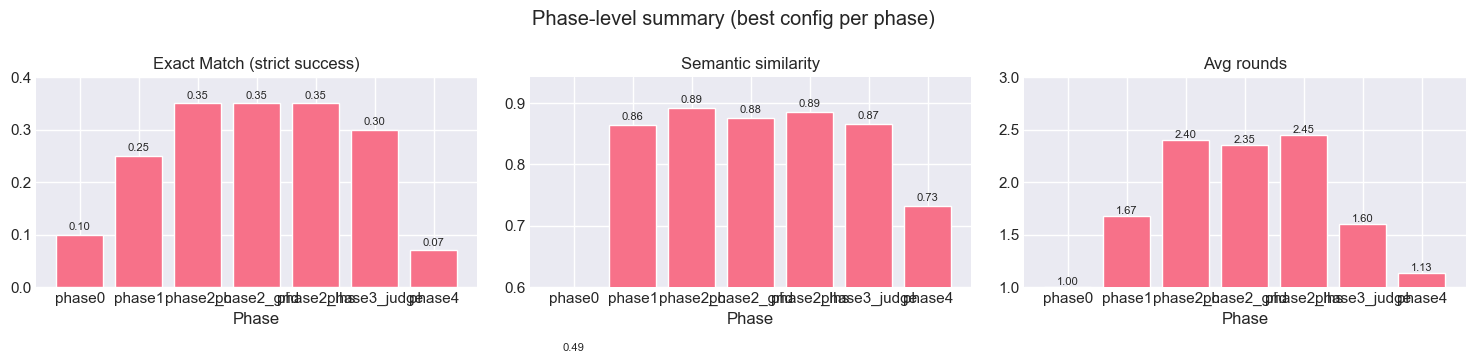

In [34]:
# CELL 2: Phase-level overview (best EM per phase)

# เลือก best experiment ต่อ phase โดยใช้ exact_match เป็นหลัก
def pick_phase_representatives(df):
    reps = []
    for ph in sorted(df['phase'].dropna().unique()):
        sub = df[df['phase'] == ph]
        if sub.empty:
            continue
        best = sub.sort_values('exact_match', ascending=False).iloc[0]
        reps.append(best)
    return pd.DataFrame(reps)

df_phase_rep = pick_phase_representatives(df_all)
print("Phase representatives:")
display(df_phase_rep[['phase', 'experiment_id', 'teacher', 'student',
                      'domain', 'mode', 'exact_match', 'semantic', 'avg_rounds']])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = df_phase_rep['phase']

for ax, metric, title in zip(
    axes,
    ['exact_match', 'semantic', 'avg_rounds'],
    ['Exact Match (strict success)', 'Semantic similarity', 'Avg rounds']
):
    ax.bar(x, df_phase_rep[metric])
    ax.set_title(title)
    ax.set_xlabel('Phase')
    ax.set_ylabel('')
    for xi, v in zip(x, df_phase_rep[metric]):
        ax.text(xi, v + 0.005, f"{v:.2f}", ha='center', va='bottom', fontsize=8)

axes[0].set_ylim(0, max(0.4, df_phase_rep['exact_match'].max() + 0.05))
axes[1].set_ylim(0.6, min(1.0, df_phase_rep['semantic'].max() + 0.05))
axes[2].set_ylim(1.0, max(3.0, df_phase_rep['avg_rounds'].max() + 0.2))

plt.suptitle("Phase-level summary (best config per phase)")
plt.tight_layout()
plt.show()


Phase 1 rows:


,experiment_id,teacher,student,exact_match,semantic,avg_rounds
1,phase1_cot_feedback_minimal,cot_feedback,minimal,0.250000,0.864879,1.675000
2,phase1_cot_feedback_reflective,cot_feedback,reflective,0.000000,0.591729,2.525000
3,phase1_cot_feedback_simple_minimal,cot_feedback,simple_minimal,0.200000,0.834286,1.725000
4,phase1_cot_feedback_structured,cot_feedback,structured,0.000000,0.723281,1.975000
5,phase1_feedback_default,feedback,default,0.160000,0.000000,2.250000
6,phase1_feedback_reflective,feedback,reflective,0.190000,0.000000,2.220000
7,phase1_feedback_structured,feedback,structured,0.180000,0.000000,2.230000
8,phase1_socratic_feedback_default,socratic_feedback,default,0.170000,0.000000,2.230000
9,phase1_socratic_feedback_minimal,socratic_feedback,minimal,0.200000,0.765322,1.800000
10,phase1_socratic_feedback_reflective,socratic_feedback,reflective,0.053333,0.384545,2.420000


Student summary (Phase 1):


,student,exact_match,semantic,avg_rounds
0,default,0.166667,0.000000,2.233333
1,minimal,0.216667,0.804779,1.758333
2,reflective,0.082083,0.313958,2.383750
3,simple_minimal,0.200000,0.806696,1.775000
4,structured,0.083333,0.387790,2.094583


C:\Users\ham25\AppData\Local\Temp\ipykernel_18452\3236006851.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


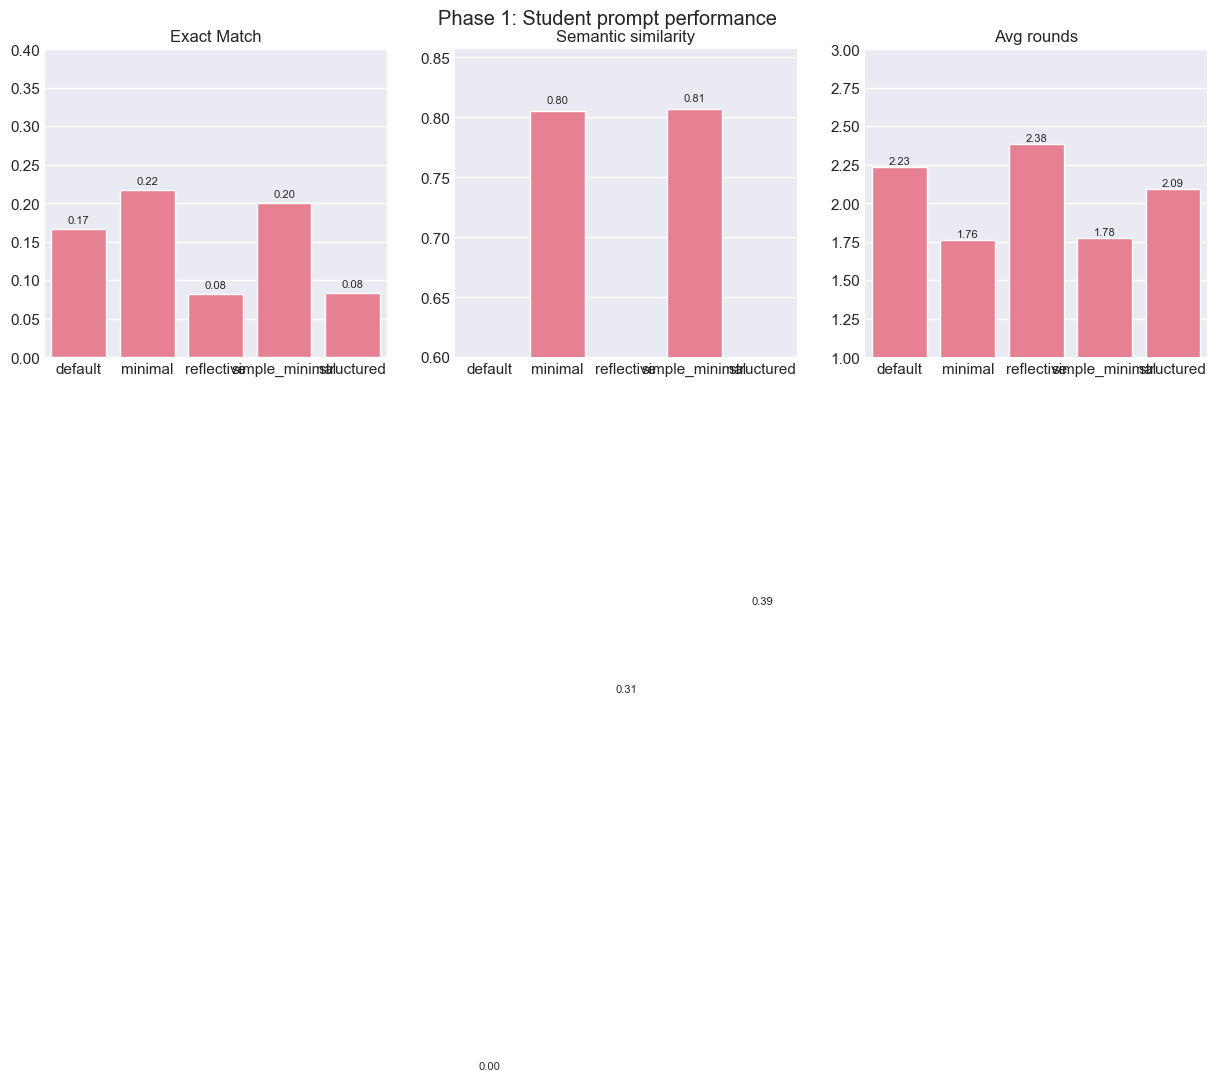

Teacher summary (Phase 1):


,teacher,exact_match,semantic,avg_rounds
0,cot_feedback,0.112500,0.753544,1.975000
1,feedback,0.176667,0.000000,2.233333
2,socratic_feedback,0.135333,0.481422,2.078667
3,template_feedback,0.151000,0.444026,2.044000


C:\Users\ham25\AppData\Local\Temp\ipykernel_18452\3236006851.py:70: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


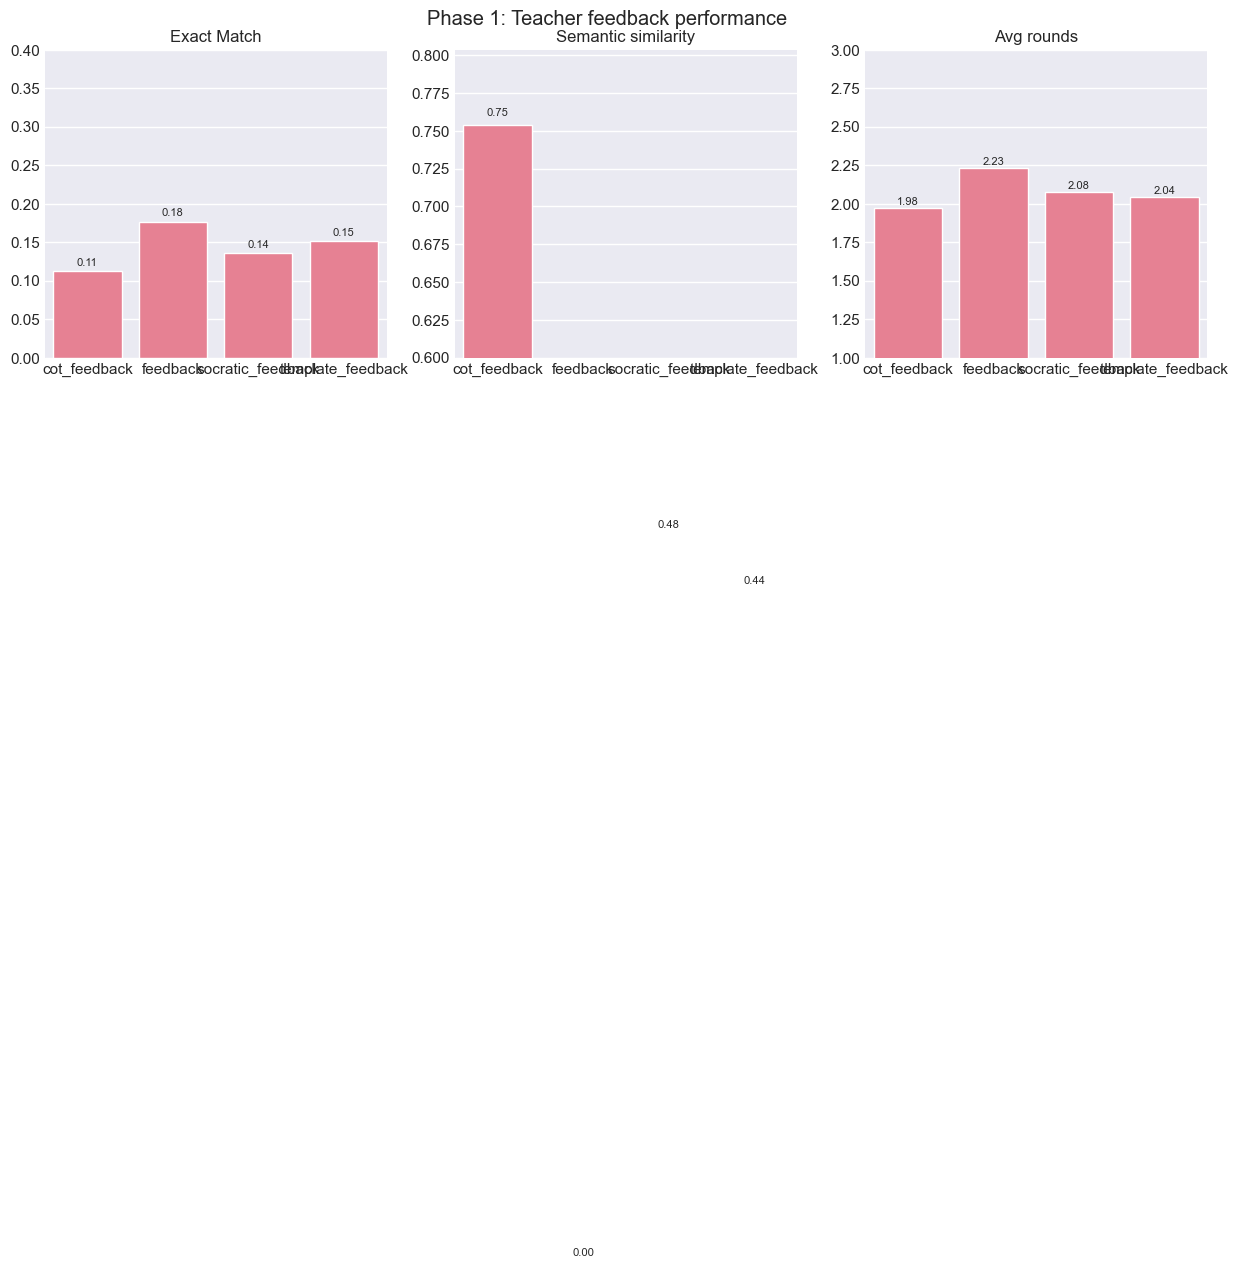

Phase 4 rows:


,experiment_id,phase,teacher,student,domain,mode,judge_mode,pass_threshold,mem_top_k,mem_sim,student_temp,teacher_temp,exact_match,rouge_l,semantic,blind,comp,avg_rounds
96,phase4_champion_mem_off_alpaca,phase4,cot_feedback,minimal,alpaca,champion_mem_off,NaN,0.897958,0.0,0.990000,0.0,0.2,0.04,0.509401,0.725059,0.8765,0.938,1.23
97,phase4_champion_mem_off_medical,phase4,cot_feedback,minimal,medical,champion_mem_off,NaN,0.897958,0.0,0.990000,0.0,0.2,0.01,0.368681,0.709626,0.8725,0.902,1.27
98,phase4_champion_mem_on_alpaca,phase4,cot_feedback,minimal,alpaca,champion_mem_on,NaN,0.897958,3.0,0.835631,0.0,0.2,0.07,0.534407,0.731712,0.8770,0.942,1.13
99,phase4_champion_mem_on_medical,phase4,cot_feedback,minimal,medical,champion_mem_on,NaN,0.897958,3.0,0.835631,0.0,0.2,0.01,0.356149,0.704773,0.8725,0.897,1.25


Phase 4 summary:


,domain,mode,exact_match,semantic,rouge_l,avg_rounds
0,alpaca,champion_mem_off,0.04,0.725059,0.509401,1.23
1,alpaca,champion_mem_on,0.07,0.731712,0.534407,1.13
2,medical,champion_mem_off,0.01,0.709626,0.368681,1.27
3,medical,champion_mem_on,0.01,0.704773,0.356149,1.25


C:\Users\ham25\AppData\Local\Temp\ipykernel_18452\3236006851.py:114: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


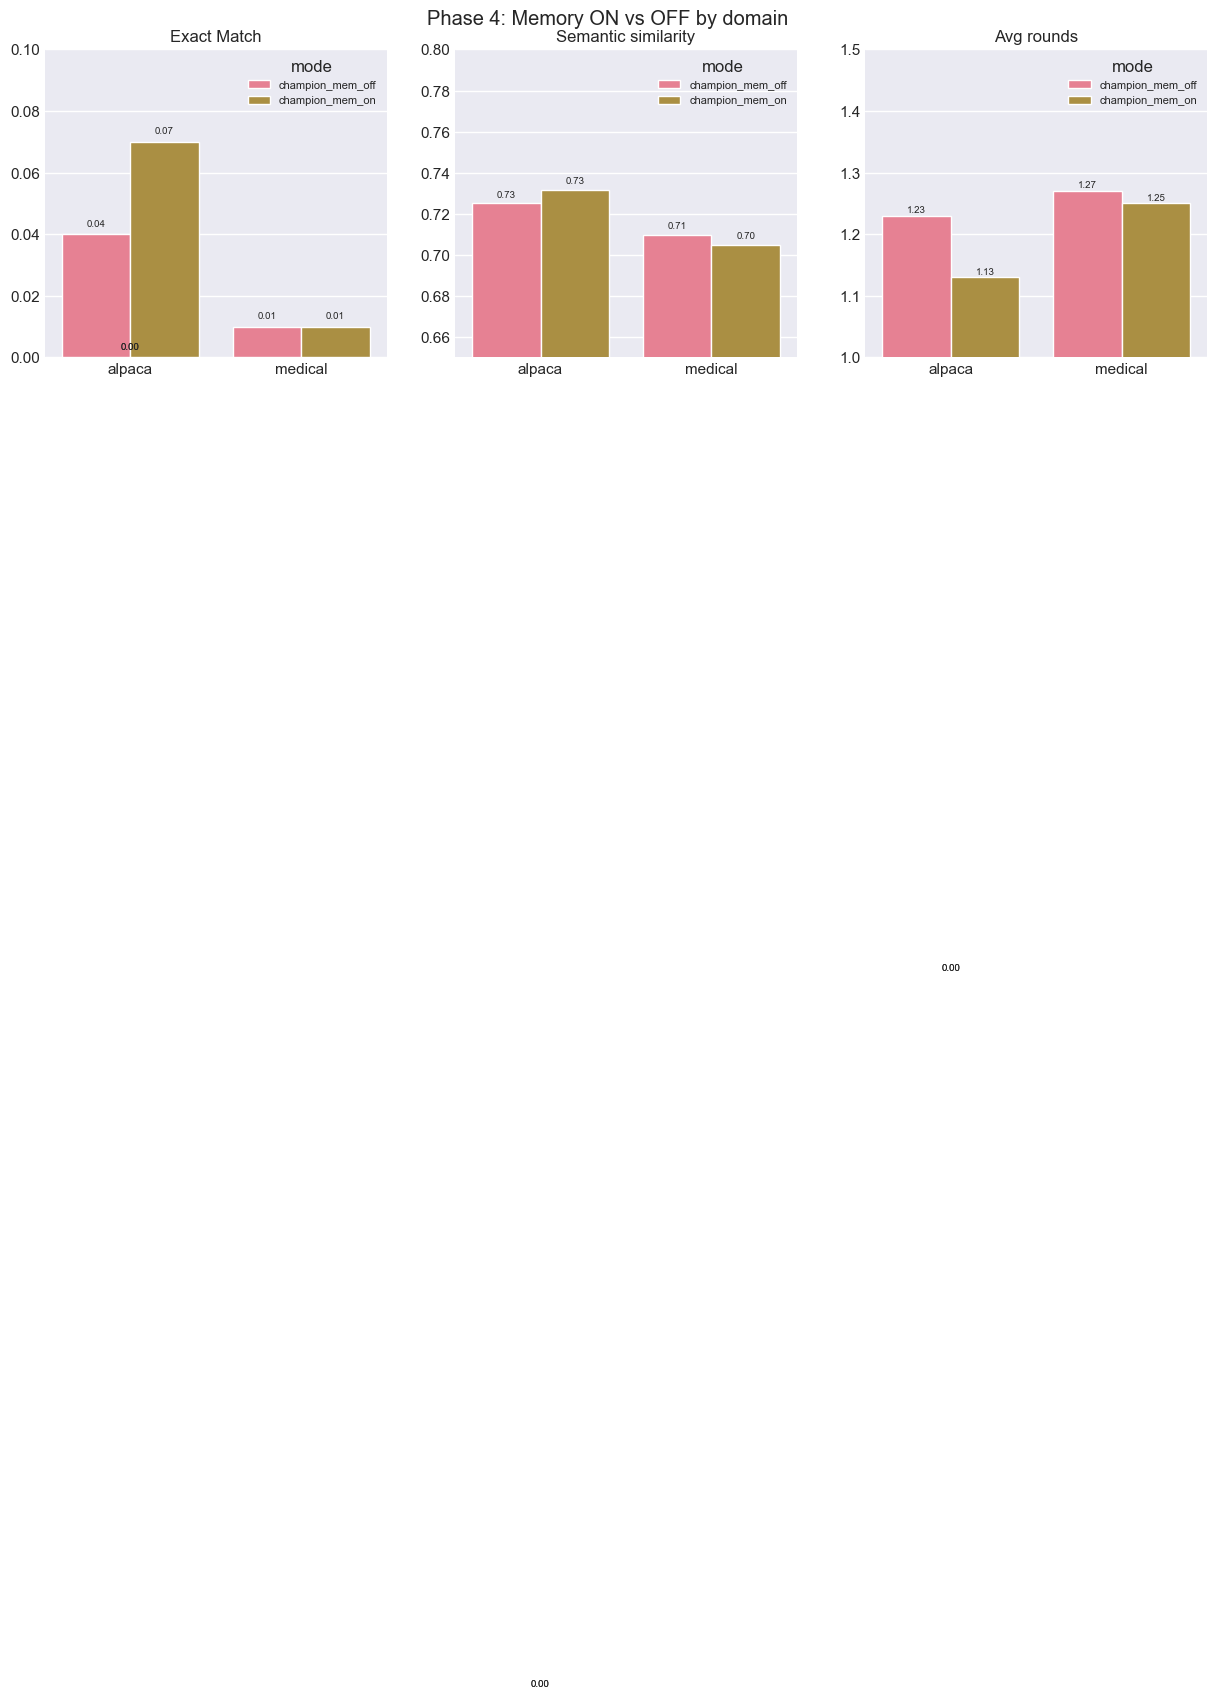

In [35]:
# CELL 3A: Teacher / Student prompt performance (Phase 1)

df_phase1 = df_all[df_all['phase'] == 'phase1'].copy()

print("Phase 1 rows:")
display(df_phase1[['experiment_id', 'teacher', 'student', 'exact_match', 'semantic', 'avg_rounds']])

# Student
student_summary = (
    df_phase1
    .groupby('student')
    .agg({
        'exact_match': 'mean',
        'semantic': 'mean',
        'avg_rounds': 'mean',
    })
    .reset_index()
)
print("Student summary (Phase 1):")
display(student_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
metrics = ['exact_match', 'semantic', 'avg_rounds']
titles = ['Exact Match', 'Semantic similarity', 'Avg rounds']

for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(data=student_summary, x='student', y=metric, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for i, v in enumerate(student_summary[metric]):
        ax.text(i, v + 0.005, f"{v:.2f}", ha='center', va='bottom', fontsize=8)

axes[0].set_ylim(0, max(0.4, student_summary['exact_match'].max() + 0.05))
axes[1].set_ylim(0.6, min(1.0, student_summary['semantic'].max() + 0.05))
axes[2].set_ylim(1.0, max(3.0, student_summary['avg_rounds'].max() + 0.2))

plt.suptitle("Phase 1: Student prompt performance")
plt.tight_layout()
plt.show()

# Teacher
teacher_summary = (
    df_phase1
    .groupby('teacher')
    .agg({
        'exact_match': 'mean',
        'semantic': 'mean',
        'avg_rounds': 'mean',
    })
    .reset_index()
)
print("Teacher summary (Phase 1):")
display(teacher_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, metric, title in zip(axes, metrics, titles):
    sns.barplot(data=teacher_summary, x='teacher', y=metric, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    for i, v in enumerate(teacher_summary[metric]):
        ax.text(i, v + 0.005, f"{v:.2f}", ha='center', va='bottom', fontsize=8)

axes[0].set_ylim(0, max(0.4, teacher_summary['exact_match'].max() + 0.05))
axes[1].set_ylim(0.6, min(1.0, teacher_summary['semantic'].max() + 0.05))
axes[2].set_ylim(1.0, max(3.0, teacher_summary['avg_rounds'].max() + 0.2))

plt.suptitle("Phase 1: Teacher feedback performance")
plt.tight_layout()
plt.show()

# CELL 3B: Phase 4 memory impact per domain

df_p4 = df_all[df_all['phase'] == 'phase4'].copy()
print("Phase 4 rows:")
display(df_p4)

summary_p4 = (
    df_p4
    .groupby(['domain', 'mode'])
    .agg({
        'exact_match': 'mean',
        'semantic': 'mean',
        'rouge_l': 'mean',
        'avg_rounds': 'mean',
    })
    .reset_index()
)
print("Phase 4 summary:")
display(summary_p4)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(
    axes,
    ['exact_match', 'semantic', 'avg_rounds'],
    ['Exact Match', 'Semantic similarity', 'Avg rounds']
):
    sns.barplot(data=summary_p4, x='domain', y=metric, hue='mode', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(title='mode', fontsize=8)
    for patch in ax.patches:
        h = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2, h + 0.002, f"{h:.2f}",
                ha='center', va='bottom', fontsize=7)

axes[0].set_ylim(0, 0.1)       # EM ใน Phase 4 อยู่แถวนี้
axes[1].set_ylim(0.65, 0.8)    # semantic
axes[2].set_ylim(1.0, 1.5)     # rounds

plt.suptitle("Phase 4: Memory ON vs OFF by domain")
plt.tight_layout()
plt.show()


df_debug columns: ['round', 'timestamp', 'question', 'answer', 'scores', 'final_score', 'passed', 'feedback_id', 'time_ms']
Round-level stats:


,round,final_score
0,1,0.814478
1,2,0.666163
2,3,0.713618
3,4,0.751676
4,5,0.705037
5,6,0.729224
6,7,0.743200
7,8,0.724989
8,9,0.865445
9,10,0.785192


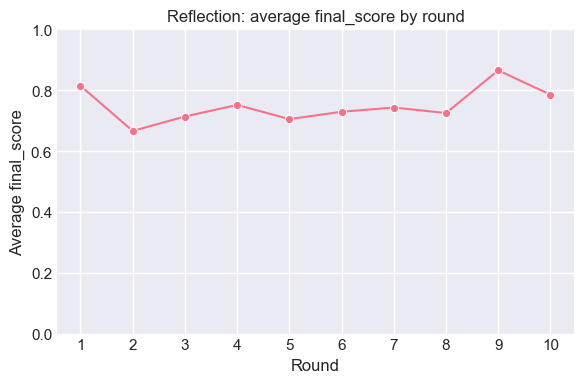


Reflection transitions summary:
  Total transitions: 251
  Improvements: 98 (39.0%)
  Degradations: 68 (27.1%)
  No change:    85 (33.9%)


In [36]:
# CELL 4: Reflection impact – per-round learning

if df_debug is None:
    print("df_debug is None – no per-round debug data found.")
else:
    print("df_debug columns:", df_debug.columns.tolist())
    if 'round' not in df_debug.columns or 'final_score' not in df_debug.columns:
        print("Expected 'round' and 'final_score' columns not found in df_debug.")
    else:
        # ค่าเฉลี่ยต่อรอบ
        round_stats = (
            df_debug
            .groupby('round')
            .agg({'final_score': 'mean'})
            .reset_index()
            .sort_values('round')
        )
        print("Round-level stats:")
        display(round_stats)

        plt.figure(figsize=(6,4))
        sns.lineplot(data=round_stats, x='round', y='final_score', marker='o')
        plt.title("Reflection: average final_score by round")
        plt.xlabel("Round")
        plt.ylabel("Average final_score")
        plt.xticks(round_stats['round'].unique())
        plt.ylim(0, 1.0)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # นับ transitions: round r -> r+1
        from collections import defaultdict

        questions = defaultdict(list)
        for entry in df_debug.to_dict(orient='records'):
            q_key = entry.get('question', '')[:80]
            questions[q_key].append((entry['round'], entry['final_score']))

        improvements, degradations, no_changes = [], [], []
        for q, rounds in questions.items():
            if len(rounds) < 2:
                continue
            rounds_sorted = sorted(rounds, key=lambda x: x[0])
            for (r1, s1), (r2, s2) in zip(rounds_sorted[:-1], rounds_sorted[1:]):
                delta = s2 - s1
                if delta > 0.01:
                    improvements.append(delta)
                elif delta < -0.01:
                    degradations.append(delta)
                else:
                    no_changes.append(delta)

        total_trans = len(improvements) + len(degradations) + len(no_changes)
        print("\nReflection transitions summary:")
        print(f"  Total transitions: {total_trans}")
        if total_trans > 0:
            print(f"  Improvements: {len(improvements)} ({len(improvements)/total_trans*100:.1f}%)")
            print(f"  Degradations: {len(degradations)} ({len(degradations)/total_trans*100:.1f}%)")
            print(f"  No change:    {len(no_changes)} ({len(no_changes)/total_trans*100:.1f}%)")


# 5. Last Phase
summerise all information and comparing baseline wiht champion config

In [4]:
# PHASE 5 SETUP
# =============

import json
import random
from pathlib import Path
from datetime import datetime as _dt

import numpy as np

# Optional: seed torch as well for reproducibility
PHASE5_SEED = 42
random.seed(PHASE5_SEED)
np.random.seed(PHASE5_SEED)
try:
    import torch
    torch.manual_seed(PHASE5_SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(PHASE5_SEED)
except ImportError:
    pass

# ---------- MAIN (full experiment) paths ----------
PHASE5_MAIN_ROOT = project_root / "logs" / "phase5_full_experiment"
PHASE5_MAIN_ROOT.mkdir(parents=True, exist_ok=True)

PHASE5_MAIN_DEBUG_DIR = PHASE5_MAIN_ROOT / "debug"
PHASE5_MAIN_DEBUG_DIR.mkdir(parents=True, exist_ok=True)

PHASE5_MAIN_ORG_DIR = project_root / "logs" / "organized_data" / "phase5_full_experiment"
PHASE5_MAIN_ORG_DIR.mkdir(parents=True, exist_ok=True)

PHASE5_SUMMARY_MAIN = PHASE5_MAIN_ORG_DIR / "summary.jsonl"
PHASE5_MAIN_DEBUG_ROUNDS = PHASE5_MAIN_ROOT / "debug_per_round.jsonl"

# ---------- TEST paths (dry-run 5 Q) ----------
PHASE5_TEST_ROOT = project_root / "logs" / "phase5_full_experiment_test"
PHASE5_TEST_ROOT.mkdir(parents=True, exist_ok=True)

PHASE5_TEST_DEBUG_DIR = PHASE5_TEST_ROOT / "debug"
PHASE5_TEST_DEBUG_DIR.mkdir(parents=True, exist_ok=True)

PHASE5_TEST_ORG_DIR = project_root / "logs" / "organized_data" / "phase5_full_experiment_test"
PHASE5_TEST_ORG_DIR.mkdir(parents=True, exist_ok=True)

PHASE5_SUMMARY_TEST = PHASE5_TEST_ORG_DIR / "summary.jsonl"
PHASE5_TEST_DEBUG_ROUNDS = PHASE5_TEST_ROOT / "debug_per_round.jsonl"

# ---------- Shared memory stores (Phase 5 MAIN uses mem_on) ----------
PHASE5_MEMORY_DIR = project_root / "logs" / "organized_data" / "memory_stores"
PHASE5_MEMORY_DIR.mkdir(parents=True, exist_ok=True)

print("Phase 5 MAIN summary:", PHASE5_SUMMARY_MAIN)
print("Phase 5 TEST summary:", PHASE5_SUMMARY_TEST)

# ---------- Champion config from Phase 2C ----------
phase2c_path = project_root / "logs" / "organized_data" / "phase2c_champion" / "summary.jsonl"
phase2c_records = []
with phase2c_path.open("r", encoding="utf-8") as f:
    for line in f:
        phase2c_records.append(json.loads(line))

best_2c = max(phase2c_records, key=lambda r: r["metrics"]["exact_match"])
champ_cfg = best_2c["config"]
champ_metrics = best_2c["metrics"]

print("="*80)
print("Phase 2C champion config used in Phase 5")
print("="*80)
print("Experiment ID:", best_2c["experiment_id"])
print("Teacher:", champ_cfg.get("teacher"))
print("Student:", champ_cfg.get("student"))
print("pass_threshold:", champ_cfg.get("pass_threshold"))
print("metric_weights:", champ_cfg.get("metric_weights"))
print("memory_similarity_threshold:", champ_cfg.get("memory_similarity_threshold"))
print("memory_top_k:", champ_cfg.get("memory_top_k"))
print("student_temperature:", champ_cfg.get("student_temperature"))
print("teacher_temperature:", champ_cfg.get("teacher_temperature"))


Phase 5 MAIN summary: c:\Users\ham25\Desktop\Teaching-light-weight-llm-based-project\logs\organized_data\phase5_full_experiment\summary.jsonl
Phase 5 TEST summary: c:\Users\ham25\Desktop\Teaching-light-weight-llm-based-project\logs\organized_data\phase5_full_experiment_test\summary.jsonl
Phase 2C champion config used in Phase 5
Experiment ID: phase2_c_4
Teacher: cot_feedback
Student: minimal
pass_threshold: 0.8979581727010184
metric_weights: {'blind_score': 0.24248502134532077, 'comparison_score': 0.39333727855547485, 'semantic_sim': 0.2141777000992044, 'rouge_l': 0.1, 'exact_match': 0.05}
memory_similarity_threshold: 0.8356312485568045
memory_top_k: 3
student_temperature: 0.0
teacher_temperature: 0.2


In [5]:
# PHASE 5 HELPERS
# ================

import os
from typing import Dict, Any, List, Optional

from simplified_teaching_loop import SimplifiedTeachingLoop
from src.eval.metrics import exact_match as em_metric, rouge_scores, semantic_similarity as sem_metric
from src.providers.factory import build_client


def run_phase5_baseline(
    experiment_id: str,
    dataset: List[Dict[str, Any]],
    base_config: Dict[str, Any],
    domain: str,
    phase_label: str,
    summary_path: Path,
) -> Dict[str, Any]:
    """
    Baseline: student-only, no teacher, no memory.
    - ใช้ student model จาก base_config['student']
    - นับ token เฉพาะ student (ไม่รวม judge)
    - ใช้ judge เพื่อประเมิน metric แต่ไม่บวก token
    """
    print(f"\n=== Phase 5 Baseline: {experiment_id} (domain={domain}) ===")

    student_cfg = base_config["student"]

    import src.providers  # ensure providers registered

    # Student client
    student = build_client(
        provider=student_cfg["provider"],
        model=student_cfg["model"],
    )
    student_temp = student_cfg.get("temperature", 0.0)
    student_max_tokens = student_cfg.get("max_tokens", 256)

    # Judges config (re-use hybrid_scoring from base_config)
    judge_cfg = base_config.get("hybrid_scoring", {})
    blind_cfg = judge_cfg.get("blind_judge", {})
    comp_cfg = judge_cfg.get("comparison_judge", {})

    blind_judge = build_client(
        provider=blind_cfg.get("provider", "groq"),
        model=blind_cfg.get("model", "llama-3.1-8b-instant"),
    )
    comp_judge = build_client(
        provider=comp_cfg.get("provider", "groq"),
        model=comp_cfg.get("model", "llama-3.3-70b-versatile"),
    )

    student_tokens_total = 0
    results = []

    for i, item in enumerate(dataset, 1):
        q = item["question"]
        ref = item["reference"]

        # Student answer (count tokens)
        resp = student.chat(
            messages=[{"role": "user", "content": f"Answer this question concisely:\n\n{q}\n\nAnswer:"}],
            temperature=student_temp,
            max_tokens=student_max_tokens,
        )
        ans = (resp.text or "").strip()
        usage = getattr(resp, "usage", None)
        if usage is not None and getattr(usage, "total_tokens", None) is not None:
            student_tokens_total += usage.total_tokens

        # Deterministic metrics
        em = em_metric(ans, ref)
        rouge = rouge_scores(ans, ref)
        sem = sem_metric(ans, ref)

        # Blind judge prompt (fallback if template not provided)
        blind_prompt_template = judge_cfg.get("blind_judge_prompt_template")
        if blind_prompt_template:
            try:
                blind_prompt = blind_prompt_template.format(question=q, student_answer=ans)
            except Exception:
                blind_prompt = (
                    "Rate the quality of this answer on a scale 0.0 to 1.0.\n\n"
                    f"Question: {q}\nAnswer: {ans}\n\nScore:"
                )
        else:
            # Phase 5 baseline fallback prompt
            blind_prompt = (
                "Rate the quality of this answer on a scale 0.0 to 1.0.\n\n"
                f"Question: {q}\nAnswer: {ans}\n\nScore:"
            )

        blind_resp = blind_judge.chat(
            messages=[{"role": "user", "content": blind_prompt}],
            temperature=0.0,
            max_tokens=10,
        )
        try:
            blind_score = float((blind_resp.text or "").strip())
        except Exception:
            blind_score = 0.0

        # Comparison judge
        comp_prompt = f"""Compare the student answer with the reference answer.
Rate accuracy from 0.0 to 1.0.

Question: {q}
Reference: {ref}
Student: {ans}

Score:"""
        comp_resp = comp_judge.chat(
            messages=[{"role": "user", "content": comp_prompt}],
            temperature=0.0,
            max_tokens=10,
        )
        try:
            comp_score = float((comp_resp.text or "").strip())
        except Exception:
            comp_score = 0.0

        scores = {
            "exact_match": float(em),
            "rouge_l": float(rouge["rouge-l"]),
            "semantic_similarity": float(sem),
            "blind_judge": float(blind_score),
            "comparison_judge": float(comp_score),
        }
        results.append(scores)

        if i % 10 == 0:
            print(f"  Progress: {i}/{len(dataset)}")

    n = len(results)
    metrics = {
        "exact_match": sum(r["exact_match"] for r in results) / n,
        "rouge_l": sum(r["rouge_l"] for r in results) / n,
        "semantic_similarity": sum(r["semantic_similarity"] for r in results) / n,
        "blind_judge": sum(r["blind_judge"] for r in results) / n,
        "comparison_judge": sum(r["comparison_judge"] for r in results) / n,
    }

    summary = {
        "experiment_id": experiment_id,
        "phase": phase_label,
        "config": {
            "domain": domain,
            "mode": "baseline",
            "teacher": None,
            "student": "baseline",
            "pass_threshold": None,
            "metric_weights": None,
            "memory_similarity_threshold": None,
            "memory_top_k": 0,
            "student_temperature": student_temp,
            "teacher_temperature": None,
            "max_rounds": 1,
        },
        "metrics": metrics,
        "avg_rounds": 1.0,
        "memory_hits": 0,
        "memory_hit_rate": 0.0,
        "student_tokens_total": student_tokens_total,
        "teacher_tokens_total": 0,
        "student_teacher_tokens": student_tokens_total,
        "timestamp": _dt.now().isoformat(),
        "seed": PHASE5_SEED,
    }

    with summary_path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(summary) + "\n")

    print("  Baseline metrics:", metrics)
    print("  Student tokens total:", student_tokens_total)
    return summary


def run_phase5_champion(
    experiment_id: str,
    dataset: List[Dict[str, Any]],
    base_config: Dict[str, Any],
    mem_on: bool,
    domain: str,
    phase_label: str,
    summary_path: Path,
    debug_rounds_path: Path,
    debug_dir: Path,
    max_questions: Optional[int] = None,
) -> Dict[str, Any]:
    """
    Run champion config (teacher + feedback loop) with memory ON/OFF for a given domain.
    - mem_on=True: use champion memory.sim + top_k and distinct memory storage
    - mem_on=False: memory.top_k=0, similarity_threshold=0.99 (disabled)
    - Token: use loop.student.total_tokens + loop.teacher.total_tokens
    - Per-round debug: append to debug_rounds_path
    """
    print(f"\n=== Phase 5 Champion: {experiment_id} (domain={domain}, mem_on={mem_on}) ===")

    overrides: Dict[str, Any] = {}

    # Teacher scoring / weights from champion
    overrides["teacher.pass_threshold"] = champ_cfg["pass_threshold"]
    w = champ_cfg["metric_weights"]
    overrides["teacher.metrics.weights.blind_score"] = w["blind_score"]
    overrides["teacher.metrics.weights.comparison_score"] = w["comparison_score"]
    overrides["teacher.metrics.weights.semantic_sim"] = w["semantic_sim"]
    overrides["teacher.metrics.weights.rouge_l"] = w["rouge_l"]
    overrides["teacher.metrics.weights.exact_match"] = w["exact_match"]

    # Memory
    if mem_on:
        mem_sim = champ_cfg["memory_similarity_threshold"]
        mem_top_k = champ_cfg["memory_top_k"]
        overrides["memory.similarity_threshold"] = mem_sim
        overrides["memory.top_k"] = mem_top_k
        mem_path = PHASE5_MEMORY_DIR / f"phase5_{domain}_mem_on.jsonl"
        mem_index = PHASE5_MEMORY_DIR / f"phase5_{domain}_mem_on.index"
        overrides["memory.storage_path"] = str(mem_path)
        overrides["memory.index_path"] = str(mem_index)
    else:
        overrides["memory.similarity_threshold"] = 0.99
        overrides["memory.top_k"] = 0  # search() guard ensures no retrieval

    # Loop settings: allow up to 10 rounds
    overrides["loop.max_rounds"] = 10
    overrides["loop.enable_last_chance"] = False

    # Temperatures (champion)
    overrides["student.temperature"] = champ_cfg.get("student_temperature", base_config["student"]["temperature"])
    overrides["teacher.temperature"] = champ_cfg.get("teacher_temperature", base_config["teacher"]["temperature"])

    # Logging path per experiment (for DebugLogger)
    overrides["logging.log_path"] = str(debug_dir / experiment_id)

    # Create temporary config and run loop
    config_path = create_temp_config(base_config, overrides)
    try:
        loop = SimplifiedTeachingLoop(str(config_path))

        results = []
        memory_hits = 0

        data_iter = dataset if max_questions is None else dataset[:max_questions]

        with debug_rounds_path.open("a", encoding="utf-8") as f_rounds:
            for idx, item in enumerate(data_iter, 1):
                q = item["question"]
                ref = item["reference"]
                qid = item.get("id", f"{domain}_{idx}")

                r = loop.run(
                    question=q,
                    ground_truth=ref,
                    question_id=qid,
                    question_idx=idx,
                    max_rounds=10,
                    student_first_key="first_attempt",
                    student_refine_key="refinement",
                )
                results.append(r)

                # memory_hits: number of questions where round 1 used memory feedback at least once
                if r.get("history"):
                    first_round = r["history"][0]
                    if first_round.get("memory_used"):
                        memory_hits += 1

                # per-round debug log
                for rd in r.get("history", []):
                    log_rec = {
                        "phase": phase_label,
                        "experiment_id": experiment_id,
                        "domain": domain,
                        "mode": "champion_mem_on" if mem_on else "champion_mem_off",
                        "question_id": qid,
                        "round": rd["round"],
                        "question": q,
                        "answer": rd["answer"],
                        "scores": rd["scores"],
                        "final_score": rd["final_score"],
                        "passed": rd["passed"],
                        "memory_used": rd.get("memory_used", False),
                        "time_ms": rd["time_ms"],
                        "timestamp": _dt.now().isoformat(),
                    }
                    f_rounds.write(json.dumps(log_rec) + "\n")

                if idx % 10 == 0:
                    print(f"  Progress: {idx}/{len(data_iter)}")

        # Aggregate metrics using parse_result from notebook
        assert "parse_result" in globals(), "parse_result must be defined earlier in the notebook"
        all_metrics = [parse_result(r) for r in results]
        n = len(all_metrics)
        metrics = {
            "exact_match": sum(m["exact_match"] for m in all_metrics) / n,
            "rouge_l": sum(m["rouge_l"] for m in all_metrics) / n,
            "semantic_similarity": sum(m["semantic_similarity"] for m in all_metrics) / n,
            "blind_judge": sum(m["blind_judge"] for m in all_metrics) / n,
            "comparison_judge": sum(m["comparison_judge"] for m in all_metrics) / n,
        }
        avg_rounds = sum(r["num_rounds"] for r in results) / n
        mem_hit_rate = memory_hits / n if n > 0 else 0.0

        student_tokens = getattr(loop.student, "total_tokens", 0)
        teacher_tokens = getattr(loop.teacher, "total_tokens", 0)

        summary = {
            "experiment_id": experiment_id,
            "phase": phase_label,
            "config": {
                "domain": domain,
                "mode": "champion_mem_on" if mem_on else "champion_mem_off",
                "teacher": champ_cfg["teacher"],
                "student": champ_cfg["student"],
                "pass_threshold": champ_cfg["pass_threshold"],
                "metric_weights": champ_cfg["metric_weights"],
                "memory_similarity_threshold": overrides["memory.similarity_threshold"],
                "memory_top_k": overrides["memory.top_k"],
                "student_temperature": overrides["student.temperature"],
                "teacher_temperature": overrides["teacher.temperature"],
                "max_rounds": 10,
            },
            "metrics": metrics,
            "avg_rounds": avg_rounds,
            "memory_hits": memory_hits,
            "memory_hit_rate": mem_hit_rate,
            "student_tokens_total": student_tokens,
            "teacher_tokens_total": teacher_tokens,
            "student_teacher_tokens": student_tokens + teacher_tokens,
            "timestamp": _dt.now().isoformat(),
            "seed": PHASE5_SEED,
        }

        with summary_path.open("a", encoding="utf-8") as f:
            f.write(json.dumps(summary) + "\n")

        print("  Metrics:", metrics)
        print("  Avg rounds:", avg_rounds)
        print("  Memory hits:", memory_hits, "/", n, f"({mem_hit_rate*100:.1f}%)")
        print("  Tokens (student, teacher, total):", student_tokens, teacher_tokens, student_tokens + teacher_tokens)

        return summary
    finally:
        if os.path.exists(config_path):
            os.unlink(config_path)


In [5]:
# Minimal re-definition of load_dataset for Phase 5

import json
from typing import Dict, List, Optional

def load_dataset(file_path: str, max_samples: Optional[int] = None) -> List[Dict]:
    """
    Load JSONL dataset and normalize to {question, reference, id}.
    """
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_samples is not None and i >= max_samples:
                break
            record = json.loads(line)
            data.append({
                "question": record["question"],
                "reference": record.get("answer") or record.get("reference"),
                "id": record.get("id", f"q_{i}"),
            })
    return data

# Minimal helpers for Phase 5 (redefine if needed)
import json
import tempfile
import yaml
from typing import Dict

def create_temp_config(base_config: Dict, overrides: Dict) -> str:
    """
    Create temporary YAML config with dot-path overrides.
    ไม่พึ่ง cell ก่อนหน้า ใช้สำหรับ Phase 5 อย่างเดียวก็ได้
    """
    # Deep copy base config via JSON to avoid numpy/YAML tag issues
    temp_config = json.loads(json.dumps(base_config))

    # Apply overrides like "teacher.pass_threshold"
    for key_path, value in overrides.items():
        keys = key_path.split(".")
        target = temp_config
        for key in keys[:-1]:
            if key not in target:
                target[key] = {}
            target = target[key]
        target[keys[-1]] = value

    # Write to temp file
    tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".yml", delete=False, encoding="utf-8")
    yaml.dump(temp_config, tmp, default_flow_style=False)
    tmp.close()
    return tmp.name

def parse_result(result: Dict) -> Dict[str, float]:
    """
    Extract metrics from SimplifiedTeachingLoop.run() result.
    ใช้เฉพาะใน Phase 2/3/5 aggregate metric
    """
    if not result.get("history"):
        return {
            "exact_match": 0.0,
            "rouge_l": 0.0,
            "semantic_similarity": 0.0,
            "blind_judge": 0.0,
            "comparison_judge": 0.0,
        }

    last_round = result["history"][-1]
    scores = last_round.get("scores", {})

    return {
        "exact_match": scores.get("exact_match", 0.0),
        "rouge_l": scores.get("rouge_l", 0.0),
        # ใน loop ใช้ key 'semantic_sim', 'blind_score', 'comparison_score'
        "semantic_similarity": scores.get("semantic_sim", 0.0),
        "blind_judge": scores.get("blind_score", 0.0),
        "comparison_judge": scores.get("comparison_score", 0.0),
    }

print("Phase 5 helpers (create_temp_config, parse_result) ready")



Phase 5 helpers (create_temp_config, parse_result) ready


In [11]:
# PHASE 5 TEST RUN (small subset, e.g. 5 questions)
# ================================================

# Load datasets (100Q each)
alpaca_100 = load_dataset(str(project_root / "data" / "alpaca_100.jsonl"), max_samples=100)
medical_100 = load_dataset(str(project_root / "data" / "medical_all_clean.jsonl"), max_samples=100)

print("Alpaca 100:", len(alpaca_100))
print("Medical 100:", len(medical_100))


def run_phase5_all_test(max_questions: int = 5):
    results = []

    # E1 (test): baseline alpaca
    results.append(
        run_phase5_baseline(
            experiment_id="phase5_test_baseline_alpaca",
            dataset=alpaca_100[:max_questions],
            base_config=base_config,
            domain="alpaca",
            phase_label="phase5_test",
            summary_path=PHASE5_SUMMARY_TEST,
        )
    )

    # E2 (test): baseline medical
    results.append(
        run_phase5_baseline(
            experiment_id="phase5_test_baseline_medical",
            dataset=medical_100[:max_questions],
            base_config=base_config,
            domain="medical",
            phase_label="phase5_test",
            summary_path=PHASE5_SUMMARY_TEST,
        )
    )

    # E3–E6 (test): champion mem_on/off x 2 domains
    results.append(
        run_phase5_champion(
            experiment_id="phase5_test_champion_mem_on_alpaca",
            dataset=alpaca_100,
            base_config=base_config,
            mem_on=True,
            domain="alpaca",
            phase_label="phase5_test",
            summary_path=PHASE5_SUMMARY_TEST,
            debug_rounds_path=PHASE5_TEST_DEBUG_ROUNDS,
            debug_dir=PHASE5_TEST_DEBUG_DIR,
            max_questions=max_questions,
        )
    )

    results.append(
        run_phase5_champion(
            experiment_id="phase5_test_champion_mem_off_alpaca",
            dataset=alpaca_100,
            base_config=base_config,
            mem_on=False,
            domain="alpaca",
            phase_label="phase5_test",
            summary_path=PHASE5_SUMMARY_TEST,
            debug_rounds_path=PHASE5_TEST_DEBUG_ROUNDS,
            debug_dir=PHASE5_TEST_DEBUG_DIR,
            max_questions=max_questions,
        )
    )

    results.append(
        run_phase5_champion(
            experiment_id="phase5_test_champion_mem_on_medical",
            dataset=medical_100,
            base_config=base_config,
            mem_on=True,
            domain="medical",
            phase_label="phase5_test",
            summary_path=PHASE5_SUMMARY_TEST,
            debug_rounds_path=PHASE5_TEST_DEBUG_ROUNDS,
            debug_dir=PHASE5_TEST_DEBUG_DIR,
            max_questions=max_questions,
        )
    )

    results.append(
        run_phase5_champion(
            experiment_id="phase5_test_champion_mem_off_medical",
            dataset=medical_100,
            base_config=base_config,
            mem_on=False,
            domain="medical",
            phase_label="phase5_test",
            summary_path=PHASE5_SUMMARY_TEST,
            debug_rounds_path=PHASE5_TEST_DEBUG_ROUNDS,
            debug_dir=PHASE5_TEST_DEBUG_DIR,
            max_questions=max_questions,
        )
    )

    return results

# ใช้รัน test ก่อนยิง full:
# phase5_test_results = run_phase5_all_test(max_questions=5)


Alpaca 100: 100
Medical 100: 100


In [12]:
phase5_test_results = run_phase5_all_test(max_questions=5)


=== Phase 5 Baseline: phase5_test_baseline_alpaca (domain=alpaca) ===
2025-11-19 11:40:12,517 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-11-19 11:40:12,518 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400


2025-11-19 11:40:12,527 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-11-19 11:40:12,528 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-19 11:40:12,539 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=12000, RPD=1000, interval=2.00s
2025-11-19 11:40:12,540 | INFO     | provider.groq                       | Initialized llama-3.3-70b-versatile with limits: RPM=30, TPM=12000, RPD=1000
  Baseline metrics: {'exact_match': 0.2, 'rouge_l': 0.46317325841710194, 'semantic_similarity': 0.7411293029785156, 'blind_judge': 0.0, 'comparison_judge': 0.0}
  Student tokens total: 722

=== Phase 5 Baseline: phase5_test_baseline_medical (domain=medical) ===
2025-11-19 11:40:48,426 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-

In [13]:
# PHASE 5 FULL RUN (100Q/domain)
# ===============================

def run_phase5_all_full():
    results = []

    # E1: baseline alpaca
    results.append(
        run_phase5_baseline(
            experiment_id="phase5_baseline_alpaca_100",
            dataset=alpaca_100,
            base_config=base_config,
            domain="alpaca",
            phase_label="phase5",
            summary_path=PHASE5_SUMMARY_MAIN,
        )
    )

    # E2: baseline medical
    results.append(
        run_phase5_baseline(
            experiment_id="phase5_baseline_medical_100",
            dataset=medical_100,
            base_config=base_config,
            domain="medical",
            phase_label="phase5",
            summary_path=PHASE5_SUMMARY_MAIN,
        )
    )

    # E3: champion mem_on alpaca
    results.append(
        run_phase5_champion(
            experiment_id="phase5_champion_mem_on_alpaca_100",
            dataset=alpaca_100,
            base_config=base_config,
            mem_on=True,
            domain="alpaca",
            phase_label="phase5",
            summary_path=PHASE5_SUMMARY_MAIN,
            debug_rounds_path=PHASE5_MAIN_DEBUG_ROUNDS,
            debug_dir=PHASE5_MAIN_DEBUG_DIR,
            max_questions=None,
        )
    )

    # E4: champion mem_off alpaca
    results.append(
        run_phase5_champion(
            experiment_id="phase5_champion_mem_off_alpaca_100",
            dataset=alpaca_100,
            base_config=base_config,
            mem_on=False,
            domain="alpaca",
            phase_label="phase5",
            summary_path=PHASE5_SUMMARY_MAIN,
            debug_rounds_path=PHASE5_MAIN_DEBUG_ROUNDS,
            debug_dir=PHASE5_MAIN_DEBUG_DIR,
            max_questions=None,
        )
    )

    # E5: champion mem_on medical
    results.append(
        run_phase5_champion(
            experiment_id="phase5_champion_mem_on_medical_100",
            dataset=medical_100,
            base_config=base_config,
            mem_on=True,
            domain="medical",
            phase_label="phase5",
            summary_path=PHASE5_SUMMARY_MAIN,
            debug_rounds_path=PHASE5_MAIN_DEBUG_ROUNDS,
            debug_dir=PHASE5_MAIN_DEBUG_DIR,
            max_questions=None,
        )
    )

    # E6: champion mem_off medical
    results.append(
        run_phase5_champion(
            experiment_id="phase5_champion_mem_off_medical_100",
            dataset=medical_100,
            base_config=base_config,
            mem_on=False,
            domain="medical",
            phase_label="phase5",
            summary_path=PHASE5_SUMMARY_MAIN,
            debug_rounds_path=PHASE5_MAIN_DEBUG_ROUNDS,
            debug_dir=PHASE5_MAIN_DEBUG_DIR,
            max_questions=None,
        )
    )

    return results

# หลังจาก test ผ่านแล้ว ค่อยเรียก:
# phase5_full_results = run_phase5_all_full()


In [9]:
import os
import glob
from pathlib import Path

# 1) ลบ memory Phase 5 ที่เคยใช้เทส (ถ้ามี)
for pattern in [
    str(PHASE5_MEMORY_DIR / "phase5_alpaca_mem_on*"),
    str(PHASE5_MEMORY_DIR / "phase5_medical_mem_on*"),
]:
    for path in glob.glob(pattern):
        print("Removing old Phase 5 memory:", path)
        os.remove(path)

# 2) ลบ summary + per-round log ของ TEST run
for p in [PHASE5_SUMMARY_TEST, PHASE5_TEST_DEBUG_ROUNDS]:
    if p.exists():
        print("Removing old Phase 5 TEST file:", p)
        p.unlink()

# 3) ลบไฟล์ debug ราย experiment ของ TEST
for p in PHASE5_TEST_DEBUG_DIR.glob("*"):
    if p.is_file():
        print("Removing TEST debug file:", p)
        p.unlink()
    elif p.is_dir():
        import shutil
        print("Removing TEST debug dir:", p)
        shutil.rmtree(p)



Removing old Phase 5 TEST file: c:\Users\ham25\Desktop\Teaching-light-weight-llm-based-project\logs\organized_data\phase5_full_experiment_test\summary.jsonl


In [14]:
from pathlib import Path

# 1) ลบ MAIN summary/debug ถ้าเคยมี run ค้างมาก่อน (ถ้าไฟล์ไม่มีก็ไม่เป็นไร)
main_summary = project_root / "logs" / "organized_data" / "phase5_full_experiment" / "summary.jsonl"
main_rounds  = project_root / "logs" / "phase5_full_experiment" / "debug_per_round.jsonl"

for p in [main_summary, main_rounds]:
    if p.exists():
        p.unlink()
        print("Removed old MAIN file:", p)


In [15]:
phase5_full_results = run_phase5_all_full()


=== Phase 5 Baseline: phase5_baseline_alpaca_100 (domain=alpaca) ===
2025-11-19 13:27:16,502 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-11-19 13:27:16,503 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-19 13:27:16,512 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=6000, RPD=14400, interval=2.00s
2025-11-19 13:27:16,513 | INFO     | provider.groq                       | Initialized llama-3.1-8b-instant with limits: RPM=30, TPM=6000, RPD=14400
2025-11-19 13:27:16,521 | INFO     | provider.ratelimit                  | RateLimiter initialized: RPM=30, TPM=12000, RPD=1000, interval=2.00s
2025-11-19 13:27:16,521 | INFO     | provider.groq                       | Initialized llama-3.3-70b-versatile with limits: RPM=30, TPM=12000, RPD=1000
  Progress: 10/100
  Progress: 20/100
  Progress